In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/indian-classical-instrument-music-emotion-dataset/Indian Classical Instrument Music Emotion Dataset/Flute/Relax/Morning Flute Relax Music _4.mp3
/kaggle/input/indian-classical-instrument-music-emotion-dataset/Indian Classical Instrument Music Emotion Dataset/Flute/Relax/Morning Flute Relax Music _17.mp3
/kaggle/input/indian-classical-instrument-music-emotion-dataset/Indian Classical Instrument Music Emotion Dataset/Flute/Relax/Morning Flute Relax Music _7.mp3
/kaggle/input/indian-classical-instrument-music-emotion-dataset/Indian Classical Instrument Music Emotion Dataset/Flute/Relax/Morning Flute Relax Music _2.mp3
/kaggle/input/indian-classical-instrument-music-emotion-dataset/Indian Classical Instrument Music Emotion Dataset/Flute/Relax/Morning Flute Relax Music _5.mp3
/kaggle/input/indian-classical-instrument-music-emotion-dataset/Indian Classical Instrument Music Emotion Dataset/Flute/Relax/Morning Flute Relax Music _41.mp3
/kaggle/input/indian-classical-instrument-mu

In [2]:
import os

# Define your data directory
#data_directory = '/kaggle/input/indian-classical-instrument-music-emotion-dataset/Indian Classical Instrument Music Emotion Dataset/Flute'
data_directory = '/kaggle/input/indian-classical-instrument-music-emotion-dataset/Indian Classical Instrument Music Emotion Dataset'

#data_directory = '/kaggle/input/indian-musical-instrument-emotion/dataset1/Tabla'
# Get the list of folders
folders = [name for name in os.listdir(data_directory)
           if os.path.isdir(os.path.join(data_directory, name))]

# Display folder names
print("Folders in directory:")
for folder in folders:
    print(folder)

Folders in directory:
Flute
Violin
Tabla
Veena


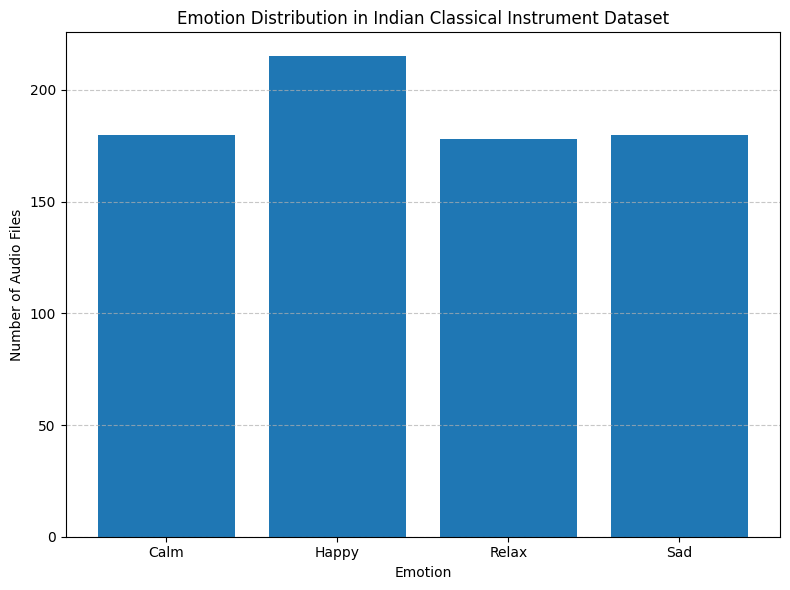

In [3]:
import os
import matplotlib.pyplot as plt
from collections import defaultdict

# Define base directory path
base_path = '/kaggle/input/indian-classical-instrument-music-emotion-dataset/Indian Classical Instrument Music Emotion Dataset'

# Dictionary to hold emotion counts
emotion_counts = defaultdict(int)

# Walk through each instrument folder
for instrument in os.listdir(base_path):
    instrument_path = os.path.join(base_path, instrument)
    
    if os.path.isdir(instrument_path):
        # For each emotion inside instrument
        for emotion in os.listdir(instrument_path):
            emotion_path = os.path.join(instrument_path, emotion)
            
            if os.path.isdir(emotion_path):
                # Count number of files in each emotion folder
                num_files = len([file for file in os.listdir(emotion_path) if file.lower().endswith(('.mp3', '.wav'))])
                emotion_counts[emotion] += num_files

# Sort emotions alphabetically for cleaner chart
sorted_emotions = sorted(emotion_counts.keys())
counts = [emotion_counts[emotion] for emotion in sorted_emotions]

# Plotting the bar chart
plt.figure(figsize=(8, 6))
plt.bar(sorted_emotions, counts)
plt.title('Emotion Distribution in Indian Classical Instrument Dataset')
plt.xlabel('Emotion')
plt.ylabel('Number of Audio Files')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

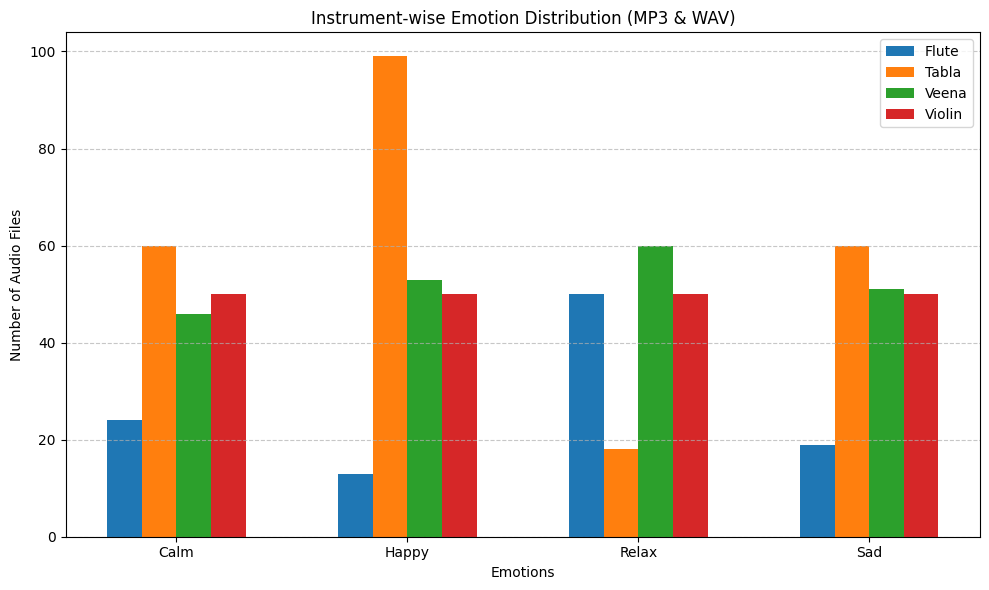

In [4]:
import os
import matplotlib.pyplot as plt
from collections import defaultdict

# Base dataset path
base_path = '/kaggle/input/indian-classical-instrument-music-emotion-dataset/Indian Classical Instrument Music Emotion Dataset'

# Nested dictionary for storing counts
instrument_emotion_counts = defaultdict(lambda: defaultdict(int))

# Accepted audio formats
audio_extensions = ('.mp3', '.wav')

# Traverse dataset
for instrument in os.listdir(base_path):
    instrument_path = os.path.join(base_path, instrument)
    
    if os.path.isdir(instrument_path):
        for emotion in os.listdir(instrument_path):
            emotion_path = os.path.join(instrument_path, emotion)
            
            if os.path.isdir(emotion_path):
                count = len([
                    file for file in os.listdir(emotion_path)
                    if file.lower().endswith(audio_extensions)
                ])
                instrument_emotion_counts[instrument][emotion] += count

# Collect all unique emotions and instruments
all_emotions = sorted({emotion for emotions in instrument_emotion_counts.values() for emotion in emotions})
all_instruments = sorted(instrument_emotion_counts.keys())

# Set up for grouped bar chart
x = range(len(all_emotions))
bar_width = 0.15

plt.figure(figsize=(10, 6))

# Plot each instrument's emotion counts
for i, instrument in enumerate(all_instruments):
    counts = [instrument_emotion_counts[instrument].get(emotion, 0) for emotion in all_emotions]
    plt.bar([p + bar_width*i for p in x], counts, width=bar_width, label=instrument)

# Format chart
plt.xlabel("Emotions")
plt.ylabel("Number of Audio Files")
plt.title("Instrument-wise Emotion Distribution (MP3 & WAV)")
plt.xticks([p + bar_width*(len(all_instruments)/2 - 0.5) for p in x], all_emotions)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Sample file selected: /kaggle/input/indian-classical-instrument-music-emotion-dataset/Indian Classical Instrument Music Emotion Dataset/Flute/Calm/Morning Flute calm Music _5.mp3


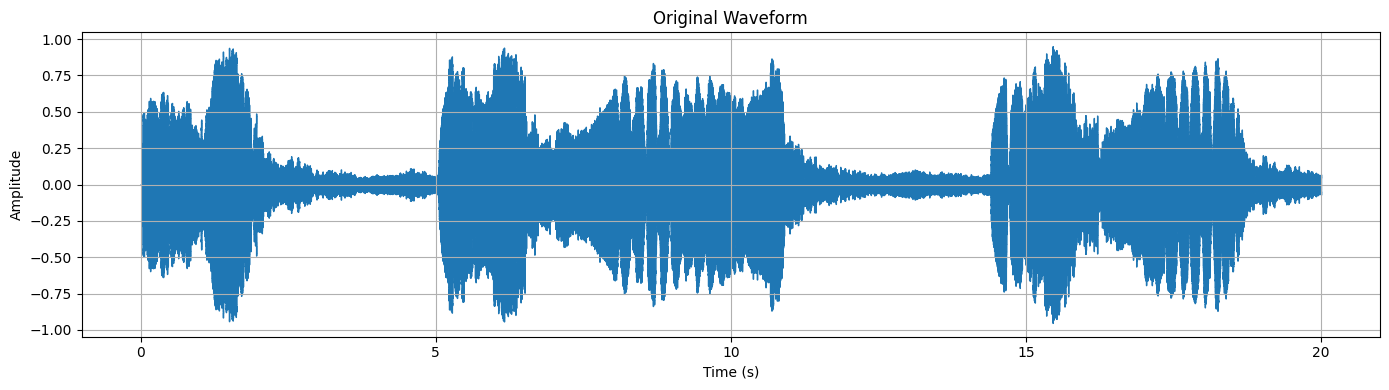

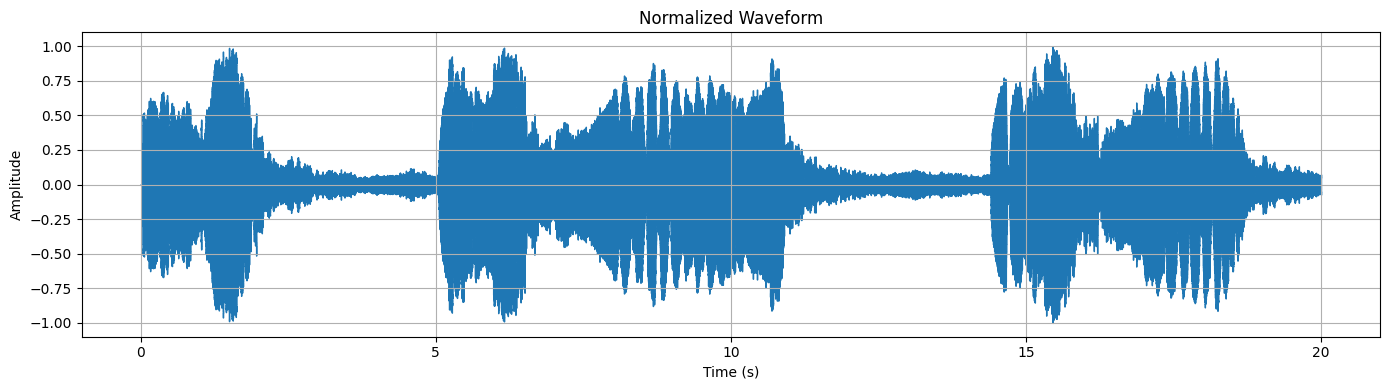

In [5]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# Step: Dynamically select a valid audio file
sample_file = None

for instrument in all_instruments:
    for emotion in all_emotions:
        folder_path = os.path.join(base_path, instrument, emotion)
        if os.path.exists(folder_path):
            for file in os.listdir(folder_path):
                if file.endswith(audio_extensions):
                    sample_file = os.path.join(folder_path, file)
                    break
        if sample_file:
            break
    if sample_file:
        break

# Check if a sample file was found
if sample_file:
    print(f"Sample file selected: {sample_file}")

    # Load audio
    y, sr = librosa.load(sample_file, duration=20)

    # Normalize audio
    y_normalized = librosa.util.normalize(y)

    # Plot original waveform
    plt.figure(figsize=(14, 4))
    librosa.display.waveshow(y, sr=sr)
    plt.title("Original Waveform")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot normalized waveform
    plt.figure(figsize=(14, 4))
    librosa.display.waveshow(y_normalized, sr=sr)
    plt.title("Normalized Waveform")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

else:
    print("No sample audio file found. Please check the dataset path and structure.")

🎵 Random Sample File Selected:
/kaggle/input/indian-classical-instrument-music-emotion-dataset/Indian Classical Instrument Music Emotion Dataset/Violin/Sad/violin-sad-calm9.mp3


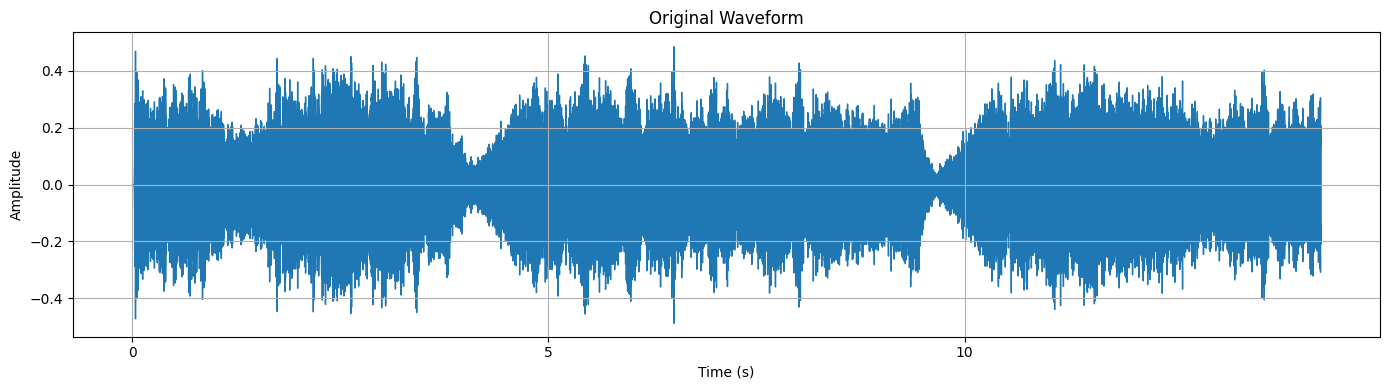

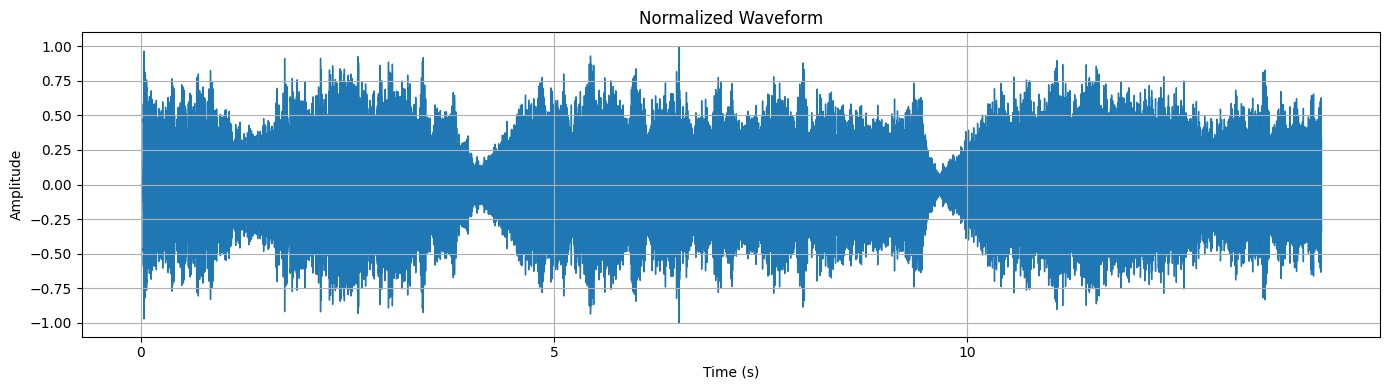

Original max amplitude: 0.4858
Normalized max amplitude: 1.0000


In [6]:
import os
import random
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# Collect all valid audio file paths
all_audio_files = []

for instrument in all_instruments:
    for emotion in all_emotions:
        folder_path = os.path.join(base_path, instrument, emotion)
        if os.path.exists(folder_path):
            for file in os.listdir(folder_path):
                if file.lower().endswith(audio_extensions):
                    full_path = os.path.join(folder_path, file)
                    all_audio_files.append(full_path)

# Randomly pick a file
if all_audio_files:
    sample_file = random.choice(all_audio_files)
    print(f"🎵 Random Sample File Selected:\n{sample_file}")

    # Load audio
    y, sr = librosa.load(sample_file, duration=20)

    # Normalize audio
    y_normalized = librosa.util.normalize(y)

    # Plot original waveform
    plt.figure(figsize=(14, 4))
    librosa.display.waveshow(y, sr=sr)
    plt.title("Original Waveform")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot normalized waveform
    plt.figure(figsize=(14, 4))
    librosa.display.waveshow(y_normalized, sr=sr)
    plt.title("Normalized Waveform")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("❌ No audio files found. Check the dataset path.")
print(f"Original max amplitude: {np.max(np.abs(y)):.4f}")
print(f"Normalized max amplitude: {np.max(np.abs(y_normalized)):.4f}")

🎵 Selected File:
/kaggle/input/indian-classical-instrument-music-emotion-dataset/Indian Classical Instrument Music Emotion Dataset/Tabla/Happy/trital80.wav


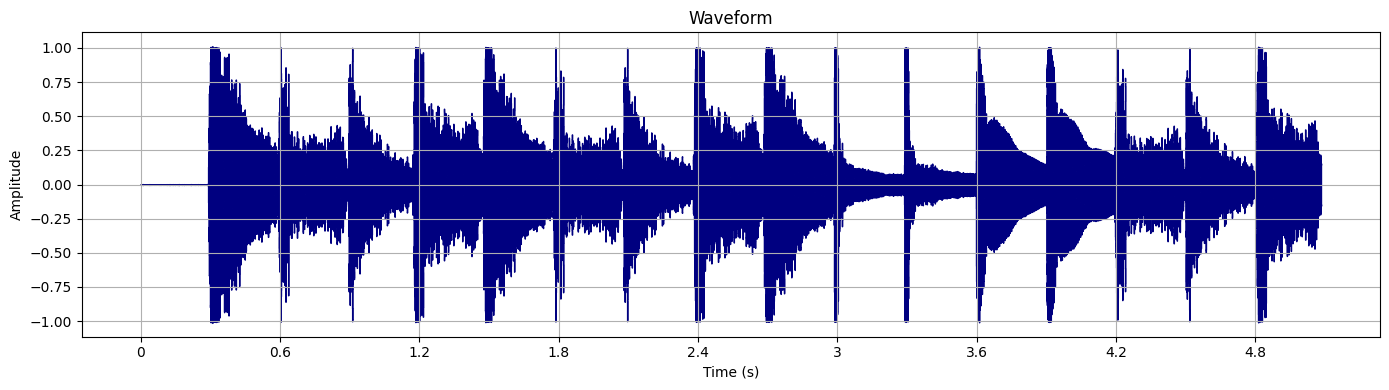

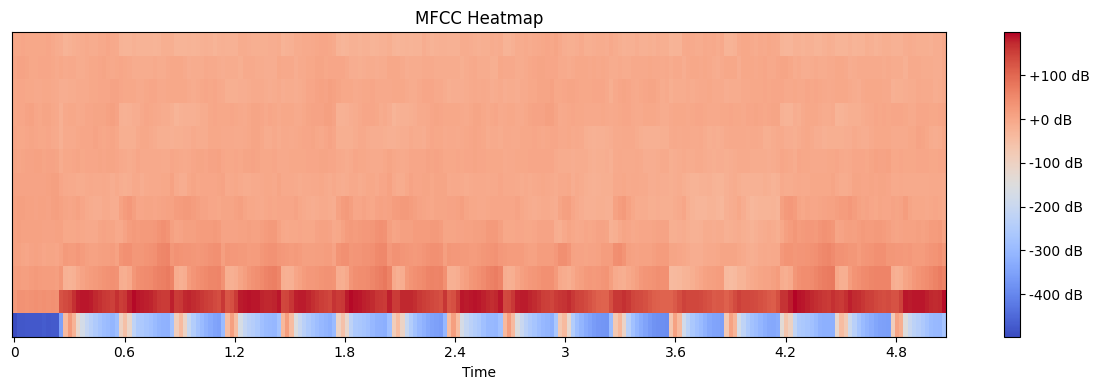

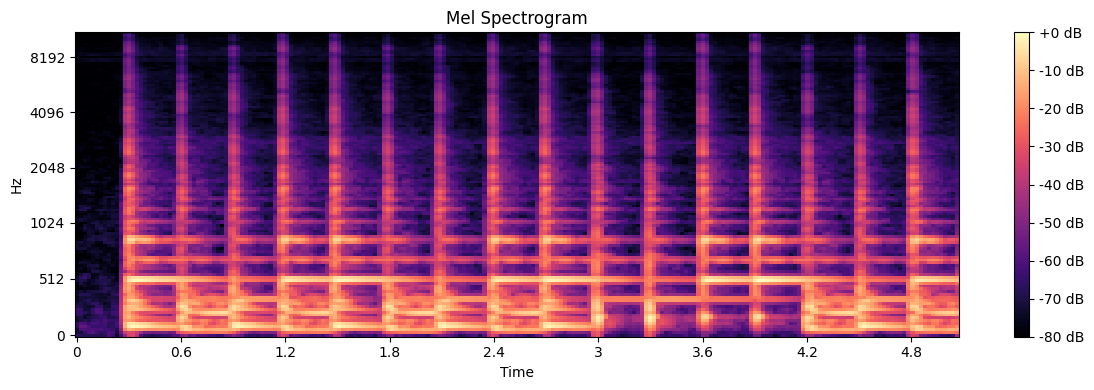

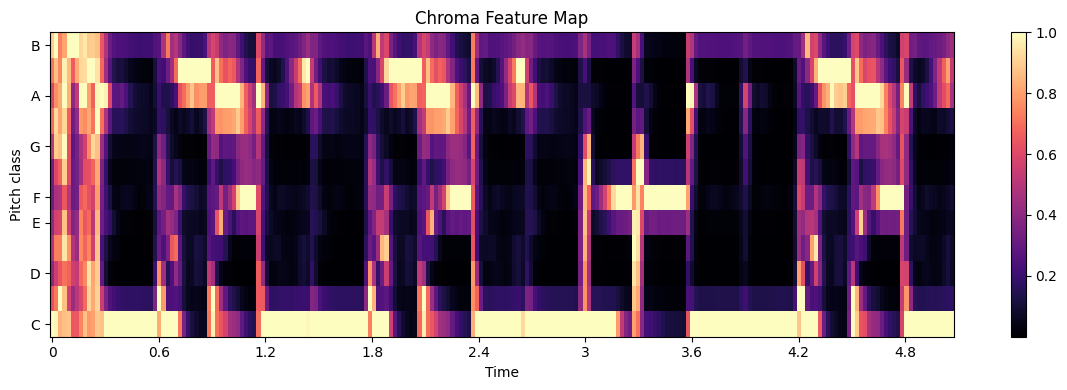

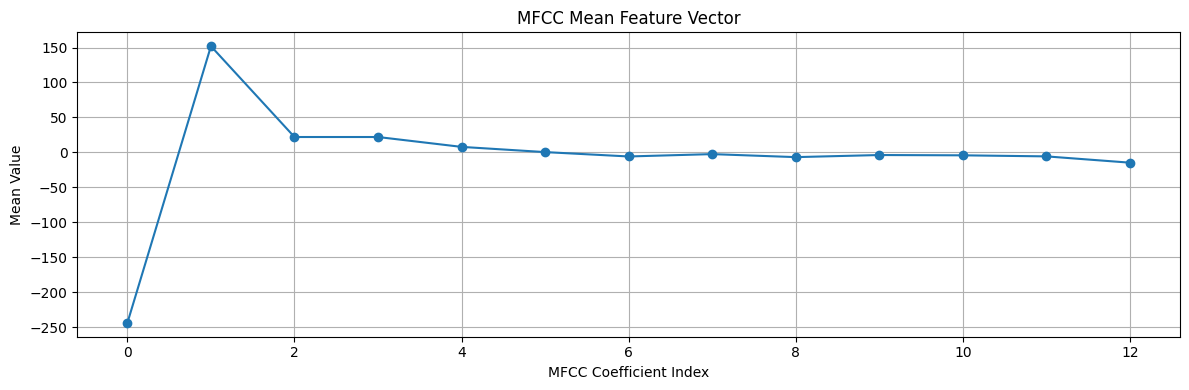

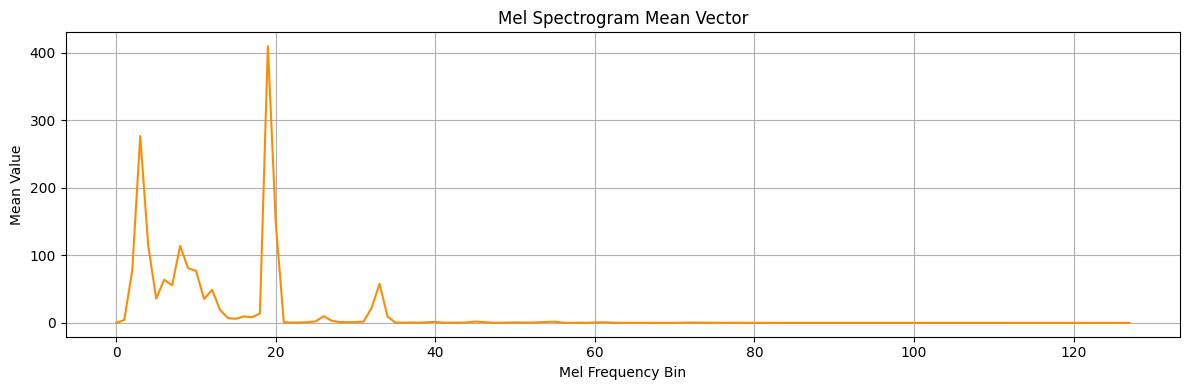

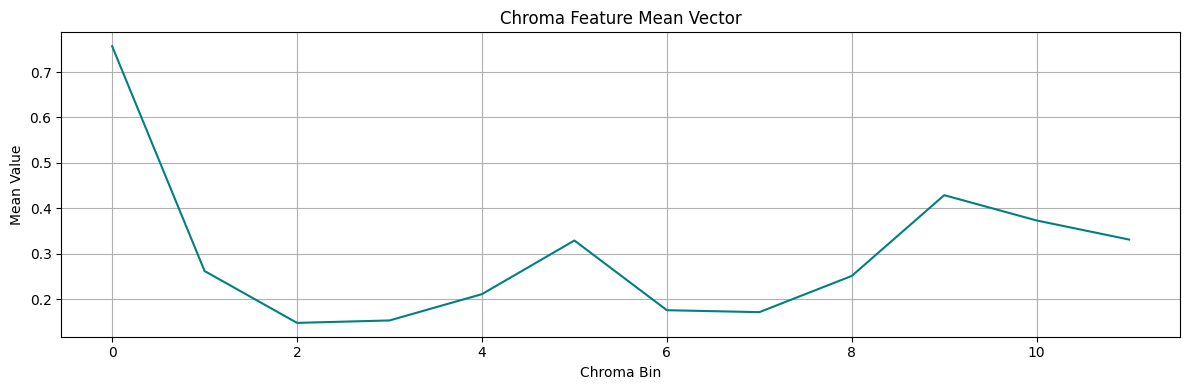

In [7]:
import os
import random
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# Collect all valid audio files
all_audio_files = []
for instrument in all_instruments:
    for emotion in all_emotions:
        folder_path = os.path.join(base_path, instrument, emotion)
        if os.path.exists(folder_path):
            for file in os.listdir(folder_path):
                if file.lower().endswith(audio_extensions):
                    all_audio_files.append(os.path.join(folder_path, file))

# Random selection
if all_audio_files:
    sample_file = random.choice(all_audio_files)
    print(f"🎵 Selected File:\n{sample_file}")

    # Load audio
    y, sr = librosa.load(sample_file, duration=20)

    # Feature extraction
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mel = librosa.feature.melspectrogram(y=y, sr=sr)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)

    # Plot all features
    plt.figure(figsize=(14, 4))
    librosa.display.waveshow(y, sr=sr, color='navy')
    plt.title('Waveform')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # MFCC heatmap
    plt.figure(figsize=(12, 4))
    librosa.display.specshow(mfcc, x_axis='time', sr=sr)
    plt.colorbar(format='%+2.0f dB')
    plt.title('MFCC Heatmap')
    plt.tight_layout()
    plt.show()

    # Mel spectrogram
    plt.figure(figsize=(12, 4))
    S_dB = librosa.power_to_db(mel, ref=np.max)
    librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr)
    plt.colorbar(format='%+2.0f dB')
    plt.title('Mel Spectrogram')
    plt.tight_layout()
    plt.show()

    # Chroma features
    plt.figure(figsize=(12, 4))
    librosa.display.specshow(chroma, x_axis='time', y_axis='chroma', sr=sr)
    plt.colorbar()
    plt.title('Chroma Feature Map')
    plt.tight_layout()
    plt.show()

    # Plot mean values of each feature
    plt.figure(figsize=(12, 4))
    plt.plot(np.mean(mfcc, axis=1), marker='o', label='MFCC Mean')
    plt.title('MFCC Mean Feature Vector')
    plt.grid(True)
    plt.xlabel('MFCC Coefficient Index')
    plt.ylabel('Mean Value')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.plot(np.mean(mel, axis=1), label='Mel Mean', color='darkorange')
    plt.title('Mel Spectrogram Mean Vector')
    plt.grid(True)
    plt.xlabel('Mel Frequency Bin')
    plt.ylabel('Mean Value')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.plot(np.mean(chroma, axis=1), label='Chroma Mean', color='teal')
    plt.title('Chroma Feature Mean Vector')
    plt.grid(True)
    plt.xlabel('Chroma Bin')
    plt.ylabel('Mean Value')
    plt.tight_layout()
    plt.show()

else:
    print("No audio files found.")

In [8]:
!pip install -q tensorflow


In [9]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Dataset path
data_directory = '/kaggle/input/indian-classical-instrument-music-emotion-dataset/Indian Classical Instrument Music Emotion Dataset'

# Step 1: Build dataframe
file_paths, instruments, emotions = [], [], []

for instrument in os.listdir(data_directory):
    instrument_path = os.path.join(data_directory, instrument)
    for file in os.listdir(instrument_path):
        if file.endswith('.wav'):
            file_paths.append(os.path.join(instrument_path, file))
            instruments.append(instrument)
            emotions.append(file.split("_")[0])

df = pd.DataFrame({'file_path': file_paths, 'instrument': instruments, 'emotion': emotions})

# Step 2: Parameters
SAMPLE_RATE = 22050
DURATION = 3
SAMPLES_PER_TRACK = SAMPLE_RATE * DURATION
N_MELS = 128

# Step 3: Feature extraction function
def extract_log_mel_spectrogram(path):
    audio_binary = tf.io.read_file(path)
    audio, _ = tf.audio.decode_wav(audio_binary)
    audio = tf.squeeze(audio, axis=-1)
    audio = audio[:SAMPLES_PER_TRACK]
    padding = tf.zeros([SAMPLES_PER_TRACK] - tf.shape(audio), dtype=tf.float32)
    audio = tf.concat([audio, padding], 0)
    
    stft = tf.signal.stft(audio, frame_length=1024, frame_step=512)
    spectrogram = tf.abs(stft)
    mel_weights = tf.signal.linear_to_mel_weight_matrix(
        num_mel_bins=N_MELS, num_spectrogram_bins=stft.shape[-1], sample_rate=SAMPLE_RATE
    )
    mel_spectrogram = tf.tensordot(spectrogram, mel_weights, axes=1)
    log_mel_spectrogram = tf.math.log(mel_spectrogram + 1e-6)
    return log_mel_spectrogram.numpy()

# Step 4: Process all files with error handling
X = []
y_emotion = []
y_instrument = []
errors = []

for idx, row in df.iterrows():
    try:
        mel = extract_log_mel_spectrogram(row['file_path'])
        mel = mel[:128, :]
        if mel.shape[0] < 128:
            mel = np.pad(mel, ((0, 128 - mel.shape[0]), (0, 0)), mode='constant')
        X.append(mel)
        y_emotion.append(row['emotion'])
        y_instrument.append(row['instrument'])
    except Exception as e:
        errors.append((row['file_path'], str(e)))

# Step 5: Diagnostics
print(f" Total valid spectrograms: {len(X)}")
print(f" Total failed: {len(errors)}")
if errors:
    print(" Sample errors:")
    for i in range(min(3, len(errors))):
        print(errors[i])

# Step 6: Skip processing if no data
if len(X) == 0:
    print(" No valid spectrograms extracted. Please check the dataset.")
else:
    # Continue with processing
    X = np.array(X)[..., np.newaxis]
    le_emotion = LabelEncoder()
    le_instrument = LabelEncoder()
    y_emotion = to_categorical(le_emotion.fit_transform(y_emotion))
    y_instrument = to_categorical(le_instrument.fit_transform(y_instrument))

    X_train, X_test, y_emotion_train, y_emotion_test, y_instr_train, y_instr_test = train_test_split(
        X, y_emotion, y_instrument, test_size=0.2, random_state=42
    )

    print(" X shape:", X.shape)
    print(" Emotion labels:", y_emotion.shape)
    print(" Instrument labels:", y_instrument.shape)


2025-10-14 09:16:41.579260: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760433401.749642      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760433401.802011      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


 Total valid spectrograms: 0
 Total failed: 0
 No valid spectrograms extracted. Please check the dataset.


In [10]:
import os
import numpy as np
import librosa

# ✅ Final Feature Extractor: Log-Mel (128x128) + Spectral Contrast + Tonnetz
def extract_combined_features(file_path, duration=3, sr=22050, n_mels=128):
    y, sr = librosa.load(file_path, sr=sr, duration=duration)
    target_len = sr * duration

    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]

    # 1. Log-Mel Spectrogram
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    log_mel = librosa.power_to_db(mel)

    # Ensure log_mel is 128x128
    if log_mel.shape[1] < 128:
        pad_width = 128 - log_mel.shape[1]
        log_mel = np.pad(log_mel, ((0, 0), (0, pad_width)), mode='constant')
    else:
        log_mel = log_mel[:, :128]

    # 2. Spectral Contrast (mean over time)
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    contrast_mean = np.mean(contrast, axis=1)  # shape: (7,)

    # 3. Tonnetz (mean over time)
    tonnetz = librosa.feature.tonnetz(y=librosa.effects.harmonic(y), sr=sr)
    tonnetz_mean = np.mean(tonnetz, axis=1)    # shape: (6,)

    # 4. Combine all features
    return log_mel, np.concatenate([contrast_mean, tonnetz_mean])  # shapes: (128,128), (13,)


In [11]:
# ✅ Initialize
X_mel_list = []
X_extra_list = []
y_label_list = []

# ✅ Dataset Path
data_path = '/kaggle/input/indian-classical-instrument-music-emotion-dataset/Indian Classical Instrument Music Emotion Dataset'

# ✅ Walk and extract
for root, dirs, files in os.walk(data_path):
    for file in files:
        if file.lower().endswith(('.wav', '.mp3')):
            try:
                file_path = os.path.join(root, file)
                parts = file_path.split('/')
                instrument = parts[-3]
                emotion = parts[-2]
                label = f"{instrument}_{emotion}"

                # Extract features
                mel_feat, extra_feat = extract_combined_features(file_path)
                X_mel_list.append(mel_feat[..., np.newaxis])  # (128,128,1)
                X_extra_list.append(extra_feat)               # (13,)
                y_label_list.append(label)

                print(f" Processed: {file_path} → {label}")

            except Exception as e:
                print(f" Error: {file_path} → {e}")

# ✅ Convert to NumPy arrays
X_mel = np.array(X_mel_list)         # Shape: (N, 128, 128, 1)
X_extra = np.array(X_extra_list)     # Shape: (N, 13)
y = np.array(y_label_list)

print("\n Feature extraction complete.")
print(f" X_mel shape: {X_mel.shape}")
print(f" X_extra shape: {X_extra.shape}")
print(f" Labels shape: {y.shape}")
print(f" Unique labels: {np.unique(y)}")


 Processed: /kaggle/input/indian-classical-instrument-music-emotion-dataset/Indian Classical Instrument Music Emotion Dataset/Flute/Relax/Morning Flute Relax Music _4.mp3 → Flute_Relax
 Processed: /kaggle/input/indian-classical-instrument-music-emotion-dataset/Indian Classical Instrument Music Emotion Dataset/Flute/Relax/Morning Flute Relax Music _17.mp3 → Flute_Relax
 Processed: /kaggle/input/indian-classical-instrument-music-emotion-dataset/Indian Classical Instrument Music Emotion Dataset/Flute/Relax/Morning Flute Relax Music _7.mp3 → Flute_Relax
 Processed: /kaggle/input/indian-classical-instrument-music-emotion-dataset/Indian Classical Instrument Music Emotion Dataset/Flute/Relax/Morning Flute Relax Music _2.mp3 → Flute_Relax
 Processed: /kaggle/input/indian-classical-instrument-music-emotion-dataset/Indian Classical Instrument Music Emotion Dataset/Flute/Relax/Morning Flute Relax Music _5.mp3 → Flute_Relax
 Processed: /kaggle/input/indian-classical-instrument-music-emotion-datase

[src/libmpg123/id3.c:process_comment():587] error: No comment text / valid description?


 Processed: /kaggle/input/indian-classical-instrument-music-emotion-dataset/Indian Classical Instrument Music Emotion Dataset/Flute/Happy/happy5.mp3 → Flute_Happy
 Processed: /kaggle/input/indian-classical-instrument-music-emotion-dataset/Indian Classical Instrument Music Emotion Dataset/Flute/Happy/happy12.wav → Flute_Happy
 Processed: /kaggle/input/indian-classical-instrument-music-emotion-dataset/Indian Classical Instrument Music Emotion Dataset/Flute/Happy/happy11.wav → Flute_Happy
 Processed: /kaggle/input/indian-classical-instrument-music-emotion-dataset/Indian Classical Instrument Music Emotion Dataset/Flute/Happy/happy8.wav → Flute_Happy
 Processed: /kaggle/input/indian-classical-instrument-music-emotion-dataset/Indian Classical Instrument Music Emotion Dataset/Flute/Calm/Morning Flute calm Music _5.mp3 → Flute_Calm
 Processed: /kaggle/input/indian-classical-instrument-music-emotion-dataset/Indian Classical Instrument Music Emotion Dataset/Flute/Calm/Morning Flute calm Music _4

[src/libmpg123/id3.c:process_comment():587] error: No comment text / valid description?


 Processed: /kaggle/input/indian-classical-instrument-music-emotion-dataset/Indian Classical Instrument Music Emotion Dataset/Violin/Happy/Violin_happy-29.mp3 → Violin_Happy
 Processed: /kaggle/input/indian-classical-instrument-music-emotion-dataset/Indian Classical Instrument Music Emotion Dataset/Violin/Happy/Violin_happy-42.mp3 → Violin_Happy
 Processed: /kaggle/input/indian-classical-instrument-music-emotion-dataset/Indian Classical Instrument Music Emotion Dataset/Violin/Happy/Violin_happy-19.mp3 → Violin_Happy
 Processed: /kaggle/input/indian-classical-instrument-music-emotion-dataset/Indian Classical Instrument Music Emotion Dataset/Violin/Happy/Violin_happy-8.mp3 → Violin_Happy
 Processed: /kaggle/input/indian-classical-instrument-music-emotion-dataset/Indian Classical Instrument Music Emotion Dataset/Violin/Happy/Violin_happy-35.mp3 → Violin_Happy
 Processed: /kaggle/input/indian-classical-instrument-music-emotion-dataset/Indian Classical Instrument Music Emotion Dataset/Violi

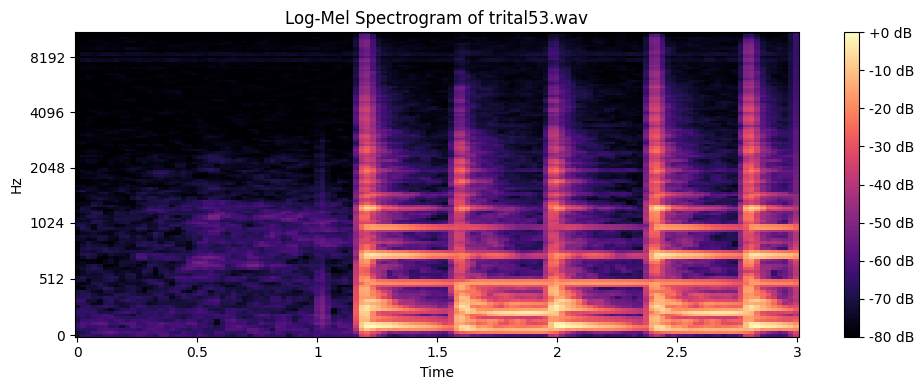

In [12]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import random

# Select a random sample from your dataset
sample_file = random.choice([os.path.join(root, file)
                             for root, _, files in os.walk(data_path)
                             for file in files if file.endswith(('.wav', '.mp3'))])

# Load the sample audio
y, sr = librosa.load(sample_file, sr=22050, duration=3)

# Generate log-mel spectrogram
n_mels = 128
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
log_S = librosa.power_to_db(S, ref=np.max)

# Display spectrogram
plt.figure(figsize=(10, 4))
librosa.display.specshow(log_S, sr=sr, x_axis='time', y_axis='mel', cmap='magma')
plt.colorbar(format='%+2.0f dB')
plt.title(f"Log-Mel Spectrogram of {os.path.basename(sample_file)}")
plt.tight_layout()
plt.show()


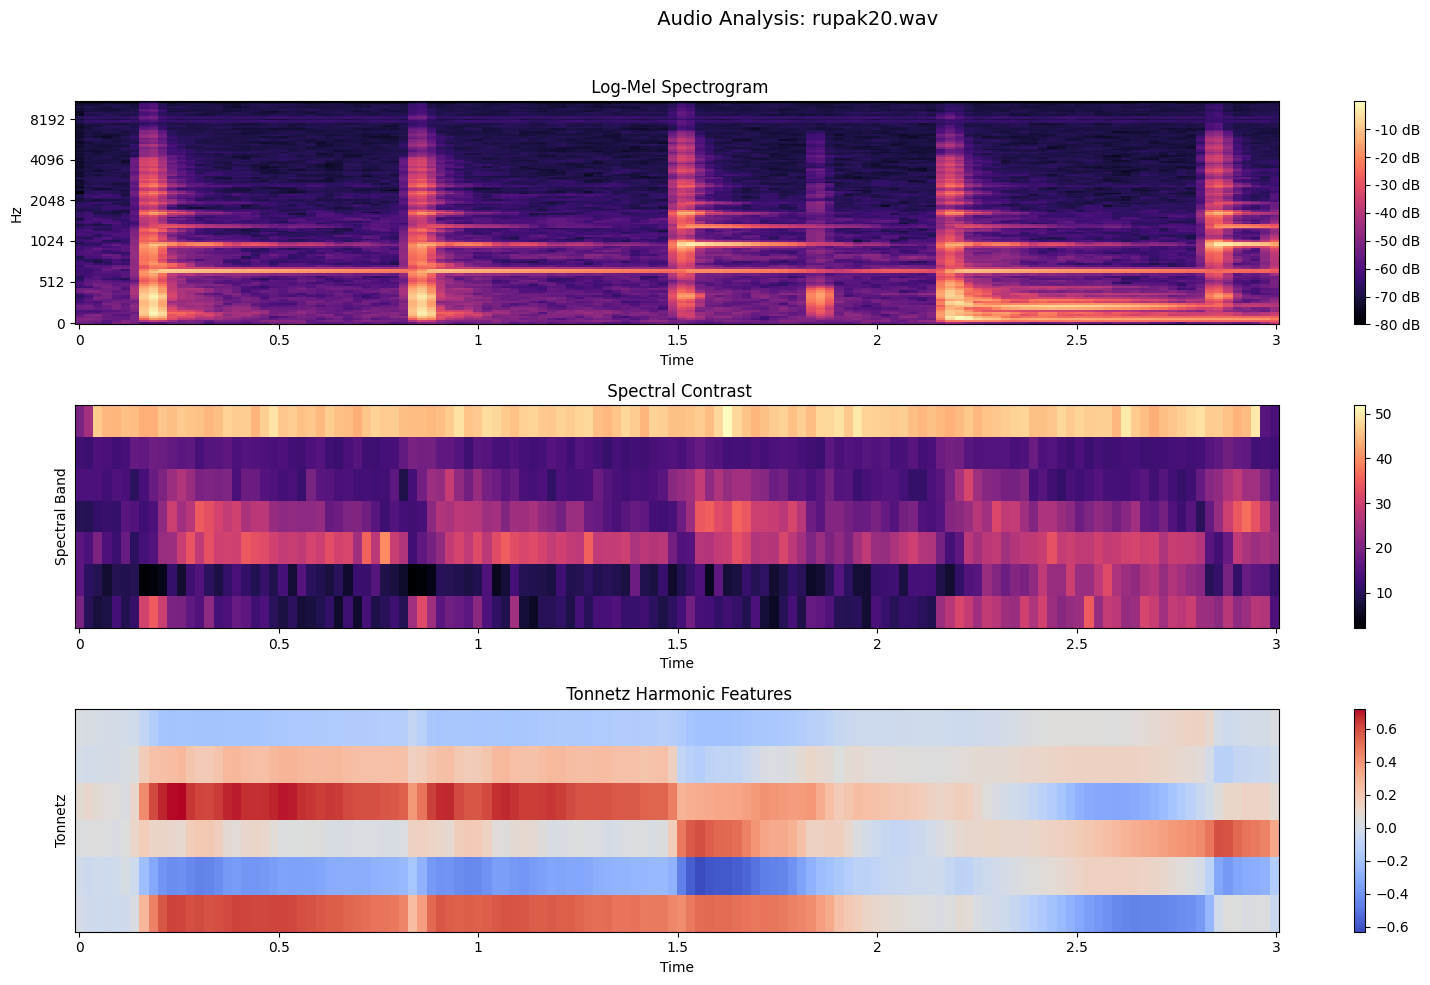

In [13]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import random
import os

# Pick a random audio file
sample_file = random.choice([
    os.path.join(root, file)
    for root, _, files in os.walk(data_path)
    for file in files if file.endswith(('.wav', '.mp3'))
])

# Load audio
y, sr = librosa.load(sample_file, sr=22050, duration=3)

# Compute Log-Mel Spectrogram
n_mels = 128
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
log_mel = librosa.power_to_db(S, ref=np.max)

# Compute Spectral Contrast
contrast = librosa.feature.spectral_contrast(y=y, sr=sr)

# Compute Tonnetz
tonnetz = librosa.feature.tonnetz(y=librosa.effects.harmonic(y), sr=sr)

# 🎯 Plot all features
plt.figure(figsize=(16, 10))

# 1. Log-Mel
plt.subplot(3, 1, 1)
librosa.display.specshow(log_mel, sr=sr, x_axis='time', y_axis='mel', cmap='magma')
plt.colorbar(format='%+2.0f dB')
plt.title(' Log-Mel Spectrogram')

# 2. Spectral Contrast
plt.subplot(3, 1, 2)
librosa.display.specshow(contrast, sr=sr, x_axis='time')
plt.colorbar()
plt.ylabel('Spectral Band')
plt.title(' Spectral Contrast')

# 3. Tonnetz
plt.subplot(3, 1, 3)
librosa.display.specshow(tonnetz, sr=sr, x_axis='time')
plt.colorbar()
plt.ylabel('Tonnetz')
plt.title(' Tonnetz Harmonic Features')

# Overall formatting
plt.suptitle(f" Audio Analysis: {os.path.basename(sample_file)}", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


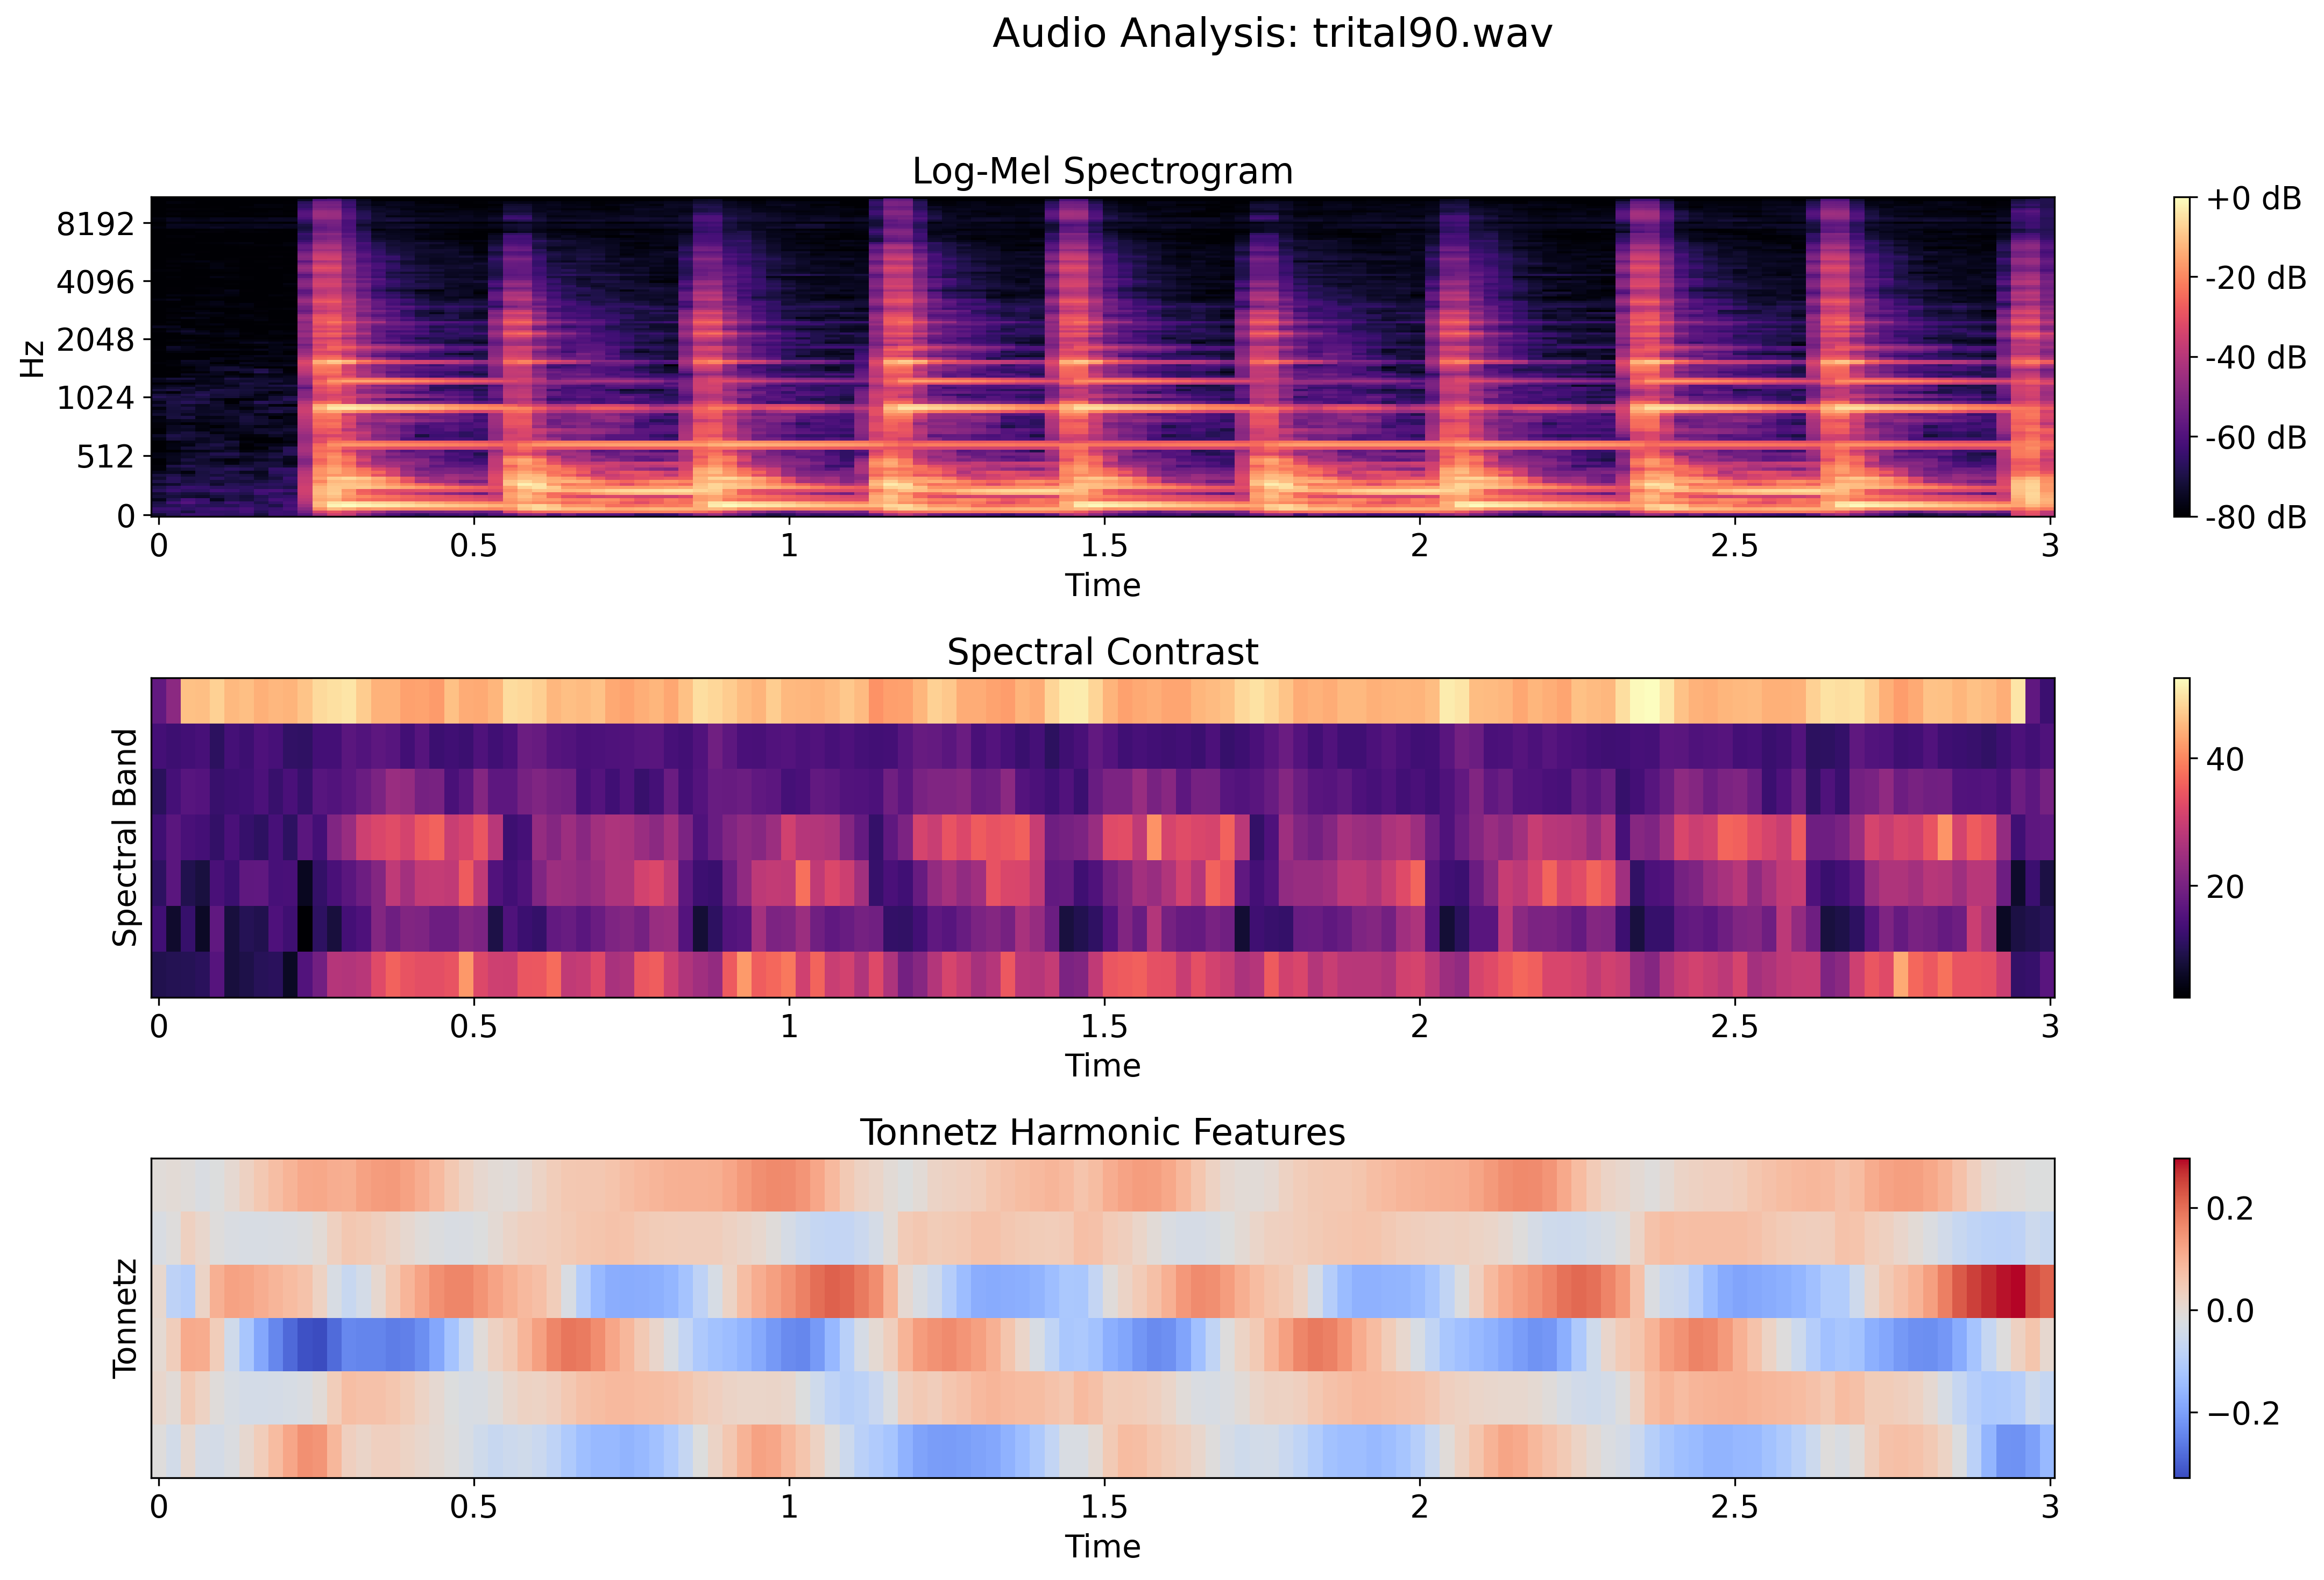

In [14]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import random
import os

# Pick a random audio file
sample_file = random.choice([
    os.path.join(root, file)
    for root, _, files in os.walk(data_path)
    for file in files if file.endswith(('.wav', '.mp3'))
])

# Load audio
y, sr = librosa.load(sample_file, sr=22050, duration=3)

# Compute Log-Mel Spectrogram
n_mels = 128
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
log_mel = librosa.power_to_db(S, ref=np.max)

# Compute Spectral Contrast
contrast = librosa.feature.spectral_contrast(y=y, sr=sr)

# Compute Tonnetz
tonnetz = librosa.feature.tonnetz(y=librosa.effects.harmonic(y), sr=sr)

# Set global font size
plt.rcParams.update({'font.size': 14})

# 🎯 Plot all features
fig = plt.figure(figsize=(16, 10), dpi=300)

# 1. Log-Mel
plt.subplot(3, 1, 1)
librosa.display.specshow(log_mel, sr=sr, x_axis='time', y_axis='mel', cmap='magma')
plt.colorbar(format='%+2.0f dB')
plt.title('Log-Mel Spectrogram', fontsize=16)

# 2. Spectral Contrast
plt.subplot(3, 1, 2)
librosa.display.specshow(contrast, sr=sr, x_axis='time')
plt.colorbar()
plt.ylabel('Spectral Band')
plt.title('Spectral Contrast', fontsize=16)

# 3. Tonnetz
plt.subplot(3, 1, 3)
librosa.display.specshow(tonnetz, sr=sr, x_axis='time')
plt.colorbar()
plt.ylabel('Tonnetz')
plt.title('Tonnetz Harmonic Features', fontsize=16)

# Overall formatting
plt.suptitle(f"Audio Analysis: {os.path.basename(sample_file)}", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


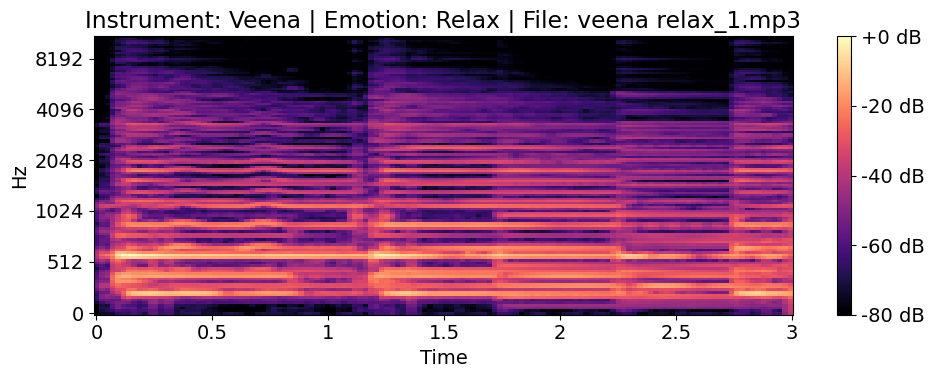

In [15]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import random
import os

# Pick a random audio file from the dataset
sample_file = random.choice([
    os.path.join(root, file)
    for root, _, files in os.walk(data_path)
    for file in files if file.endswith(('.wav', '.mp3'))
])

# Extract instrument and emotion from the path
parts = sample_file.split('/')
instrument = parts[-3]  # e.g., Flute
emotion = parts[-2]     # e.g., Relax

# Load audio
y, sr = librosa.load(sample_file, sr=22050, duration=3)

# Compute log-mel spectrogram
n_mels = 128
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
log_S = librosa.power_to_db(S, ref=np.max)

# Display the spectrogram
plt.figure(figsize=(10, 4))
librosa.display.specshow(log_S, sr=sr, x_axis='time', y_axis='mel', cmap='magma')
plt.colorbar(format='%+2.0f dB')
plt.title(f"Instrument: {instrument} | Emotion: {emotion} | File: {os.path.basename(sample_file)}")
plt.tight_layout()
plt.show()


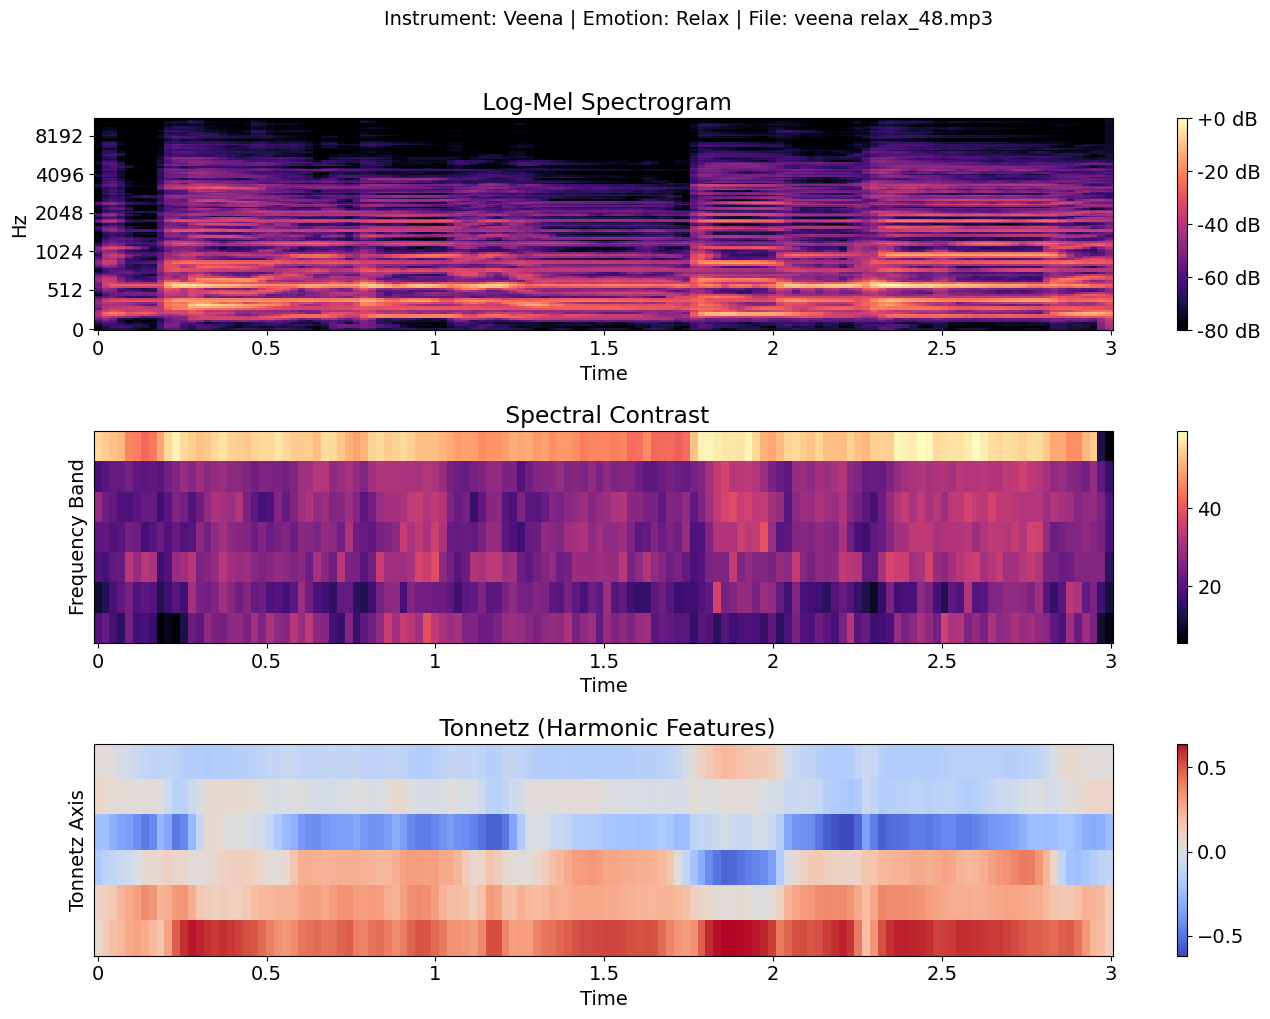

In [16]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import random
import os
import numpy as np

# Pick a random audio file from dataset
sample_file = random.choice([
    os.path.join(root, file)
    for root, _, files in os.walk(data_path)
    for file in files if file.endswith(('.wav', '.mp3'))
])

# Extract instrument and emotion from the folder path
parts = sample_file.split('/')
instrument = parts[-3]  # e.g., Flute
emotion = parts[-2]     # e.g., Sad
file_name = os.path.basename(sample_file)

# Load the audio
y, sr = librosa.load(sample_file, sr=22050, duration=3)

# Compute log-mel spectrogram
n_mels = 128
mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
log_mel = librosa.power_to_db(mel_spec, ref=np.max)

# Compute spectral contrast
spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)

# Compute tonnetz (harmonic tonality features)
harmonic_y = librosa.effects.harmonic(y)
tonnetz = librosa.feature.tonnetz(y=harmonic_y, sr=sr)

#  Plot all three feature maps
plt.figure(figsize=(14, 10))

#  Log-Mel Spectrogram
plt.subplot(3, 1, 1)
librosa.display.specshow(log_mel, sr=sr, x_axis='time', y_axis='mel', cmap='magma')
plt.colorbar(format='%+2.0f dB')
plt.title(f' Log-Mel Spectrogram')

#  Spectral Contrast
plt.subplot(3, 1, 2)
librosa.display.specshow(spectral_contrast, sr=sr, x_axis='time')
plt.colorbar()
plt.ylabel('Frequency Band')
plt.title(' Spectral Contrast')

#  Tonnetz Features
plt.subplot(3, 1, 3)
librosa.display.specshow(tonnetz, sr=sr, x_axis='time')
plt.colorbar()
plt.ylabel('Tonnetz Axis')
plt.title(' Tonnetz (Harmonic Features)')

#  Overall Title
plt.suptitle(f"Instrument: {instrument} | Emotion: {emotion} | File: {file_name}", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


/tmp/ipykernel_36/2861002799.py:41: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_36/2861002799.py:44: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


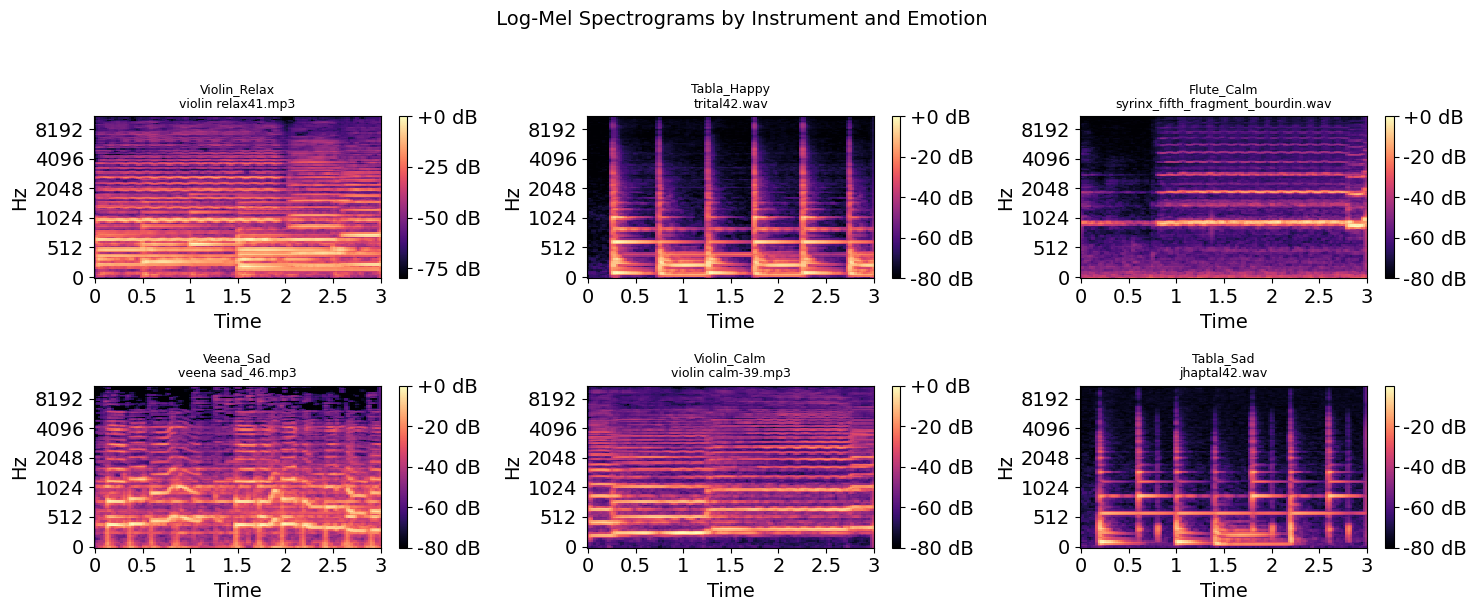

In [17]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import os
import random

# Define how many samples to show
num_samples = 6  # total spectrograms to display
rows, cols = 2, 3  # grid layout

# Collect all valid audio files with full path
all_audio_files = [
    os.path.join(root, file)
    for root, _, files in os.walk(data_path)
    for file in files if file.endswith(('.wav', '.mp3'))
]

# Shuffle and sample
random.shuffle(all_audio_files)
sampled_files = all_audio_files[:num_samples]

# Plot spectrograms
plt.figure(figsize=(15, 6))
for idx, file_path in enumerate(sampled_files):
    # Extract labels from path
    parts = file_path.split('/')
    instrument = parts[-3]
    emotion = parts[-2]
    file_name = os.path.basename(file_path)

    # Load and process audio
    y, sr = librosa.load(file_path, sr=22050, duration=3)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    log_S = librosa.power_to_db(S, ref=np.max)

    # Plot
    plt.subplot(rows, cols, idx + 1)
    librosa.display.specshow(log_S, sr=sr, x_axis='time', y_axis='mel', cmap='magma')
    plt.title(f"{instrument}_{emotion}\n{file_name}", fontsize=9)
    plt.colorbar(format='%+2.0f dB')
    plt.tight_layout()

plt.suptitle(" Log-Mel Spectrograms by Instrument and Emotion", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


/tmp/ipykernel_36/1075209261.py:44: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_36/1075209261.py:48: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.95])  # prevent title overlap


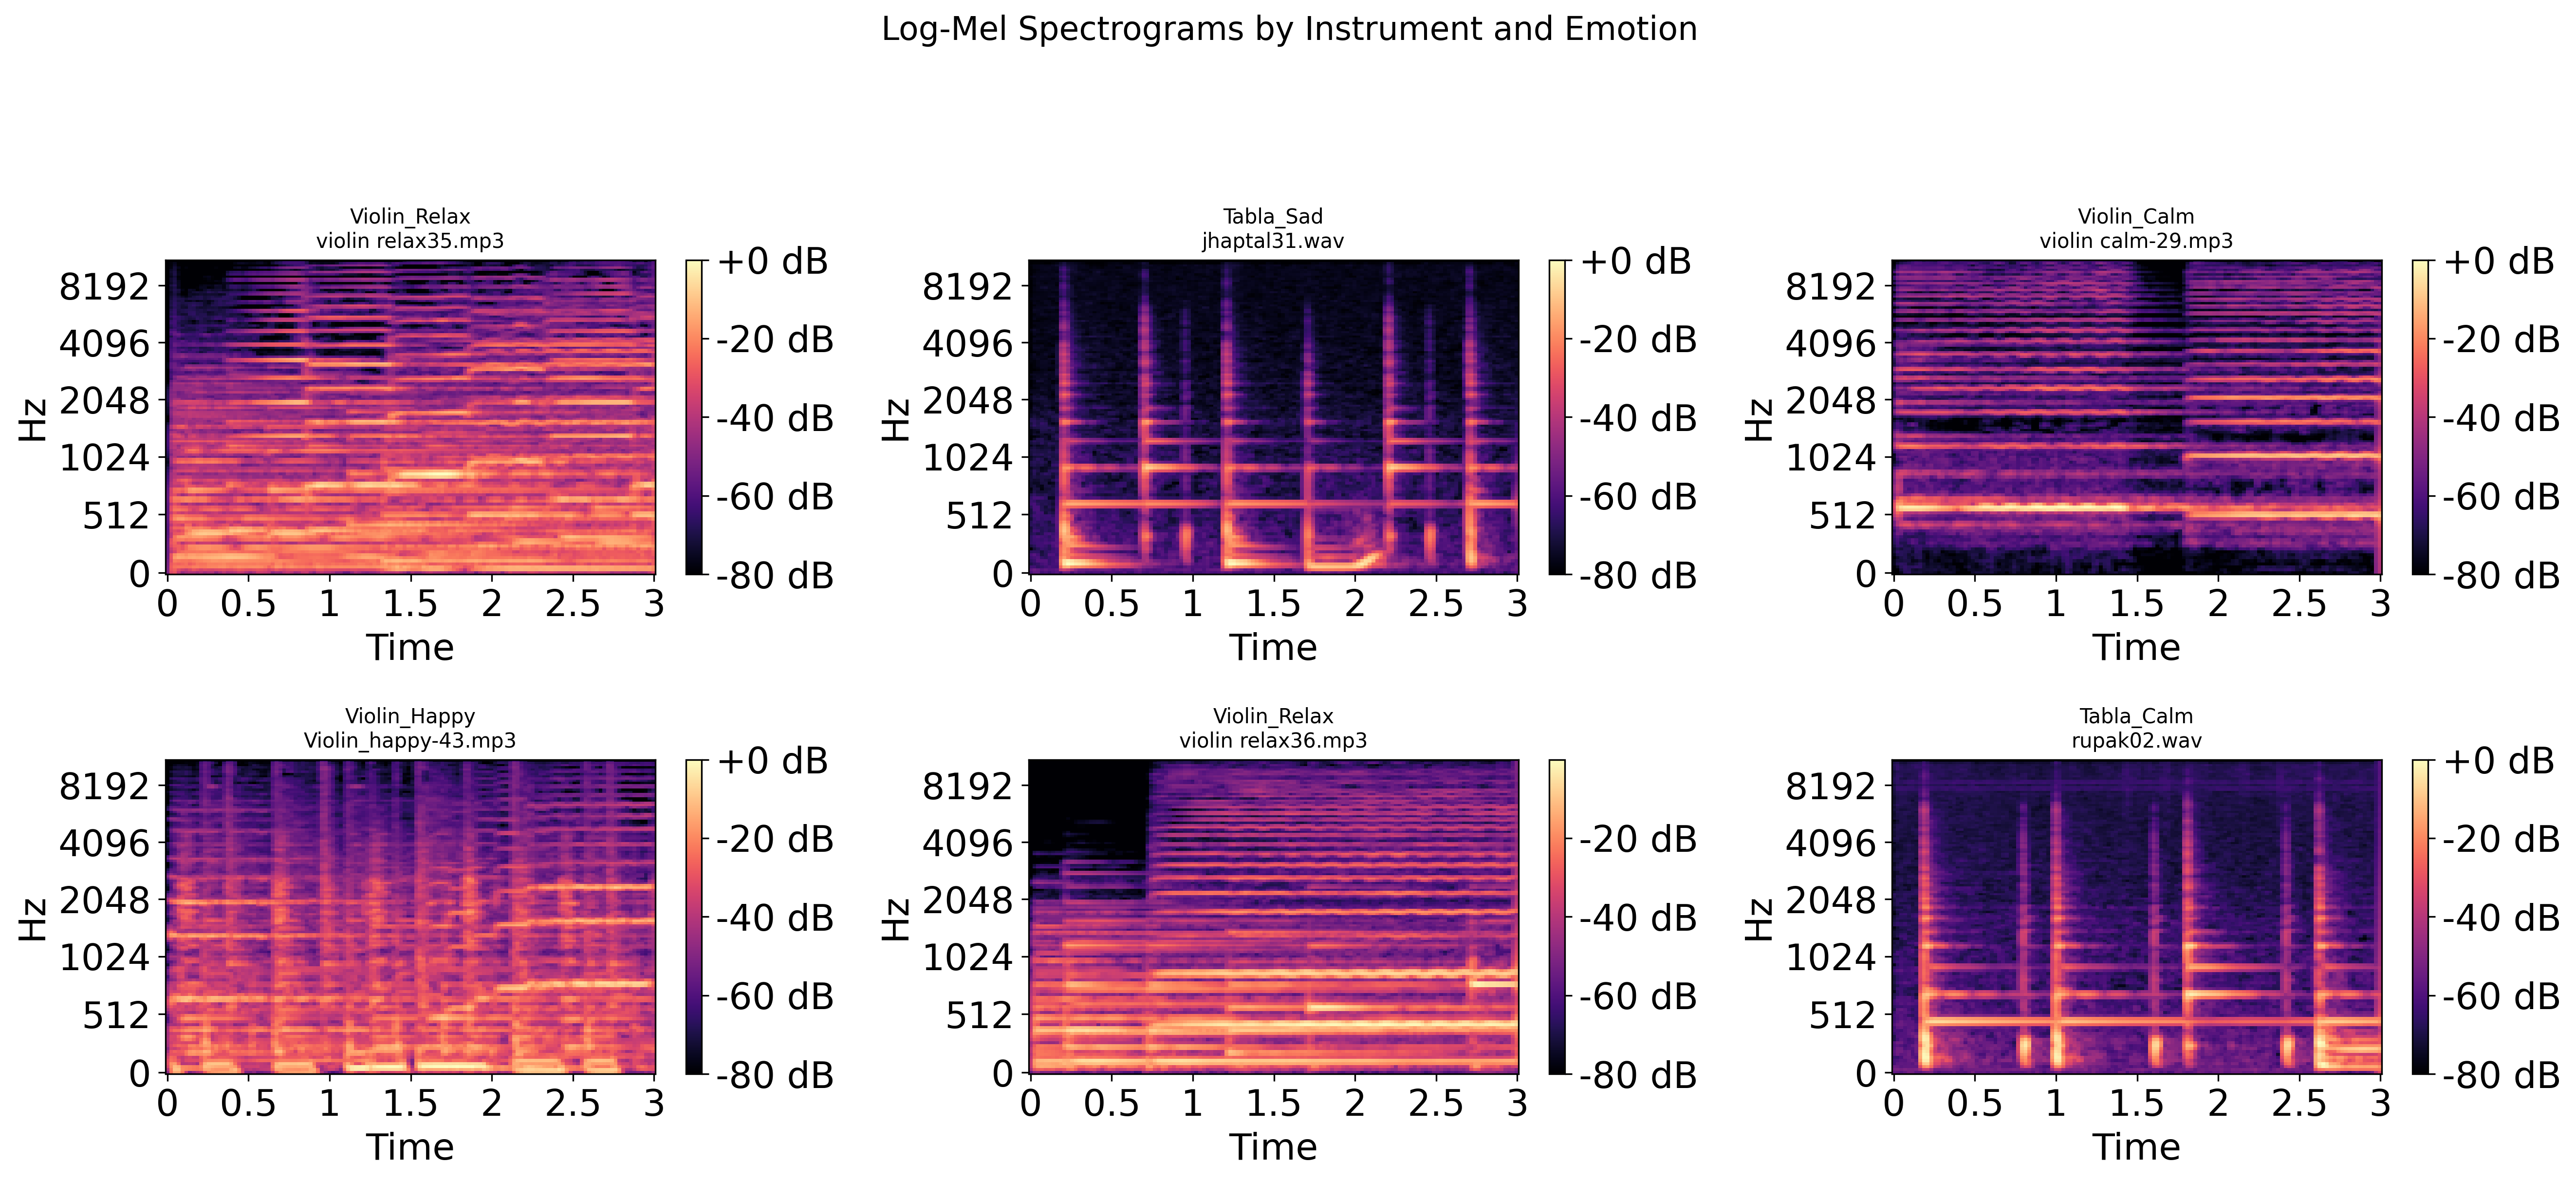

In [18]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import os
import random

# Define how many samples to show
num_samples = 6  # total spectrograms to display
rows, cols = 2, 3  # grid layout

# Collect all valid audio files with full path
all_audio_files = [
    os.path.join(root, file)
    for root, _, files in os.walk(data_path)  # use correct var if `data_path` not defined
    for file in files if file.endswith(('.wav', '.mp3'))
]

# Shuffle and sample
random.shuffle(all_audio_files)
sampled_files = all_audio_files[:num_samples]

# Set global font size
plt.rcParams.update({'font.size': 18})

# Plot spectrograms
fig = plt.figure(figsize=(18, 8), dpi=300)  # High DPI
for idx, file_path in enumerate(sampled_files):
    # Extract labels from path
    parts = file_path.split('/')
    instrument = parts[-3]
    emotion = parts[-2]
    file_name = os.path.basename(file_path)

    # Load and process audio
    y, sr = librosa.load(file_path, sr=22050, duration=3)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    log_S = librosa.power_to_db(S, ref=np.max)

    # Plot
    plt.subplot(rows, cols, idx + 1)
    librosa.display.specshow(log_S, sr=sr, x_axis='time', y_axis='mel', cmap='magma')
    plt.title(f"{instrument}_{emotion}\n{file_name}", fontsize=10)
    plt.colorbar(format='%+2.0f dB')
    plt.tight_layout()

# Super title for the figure
plt.suptitle("Log-Mel Spectrograms by Instrument and Emotion", fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # prevent title overlap
plt.show()


/tmp/ipykernel_36/1791566321.py:44: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_36/1791566321.py:48: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.96])


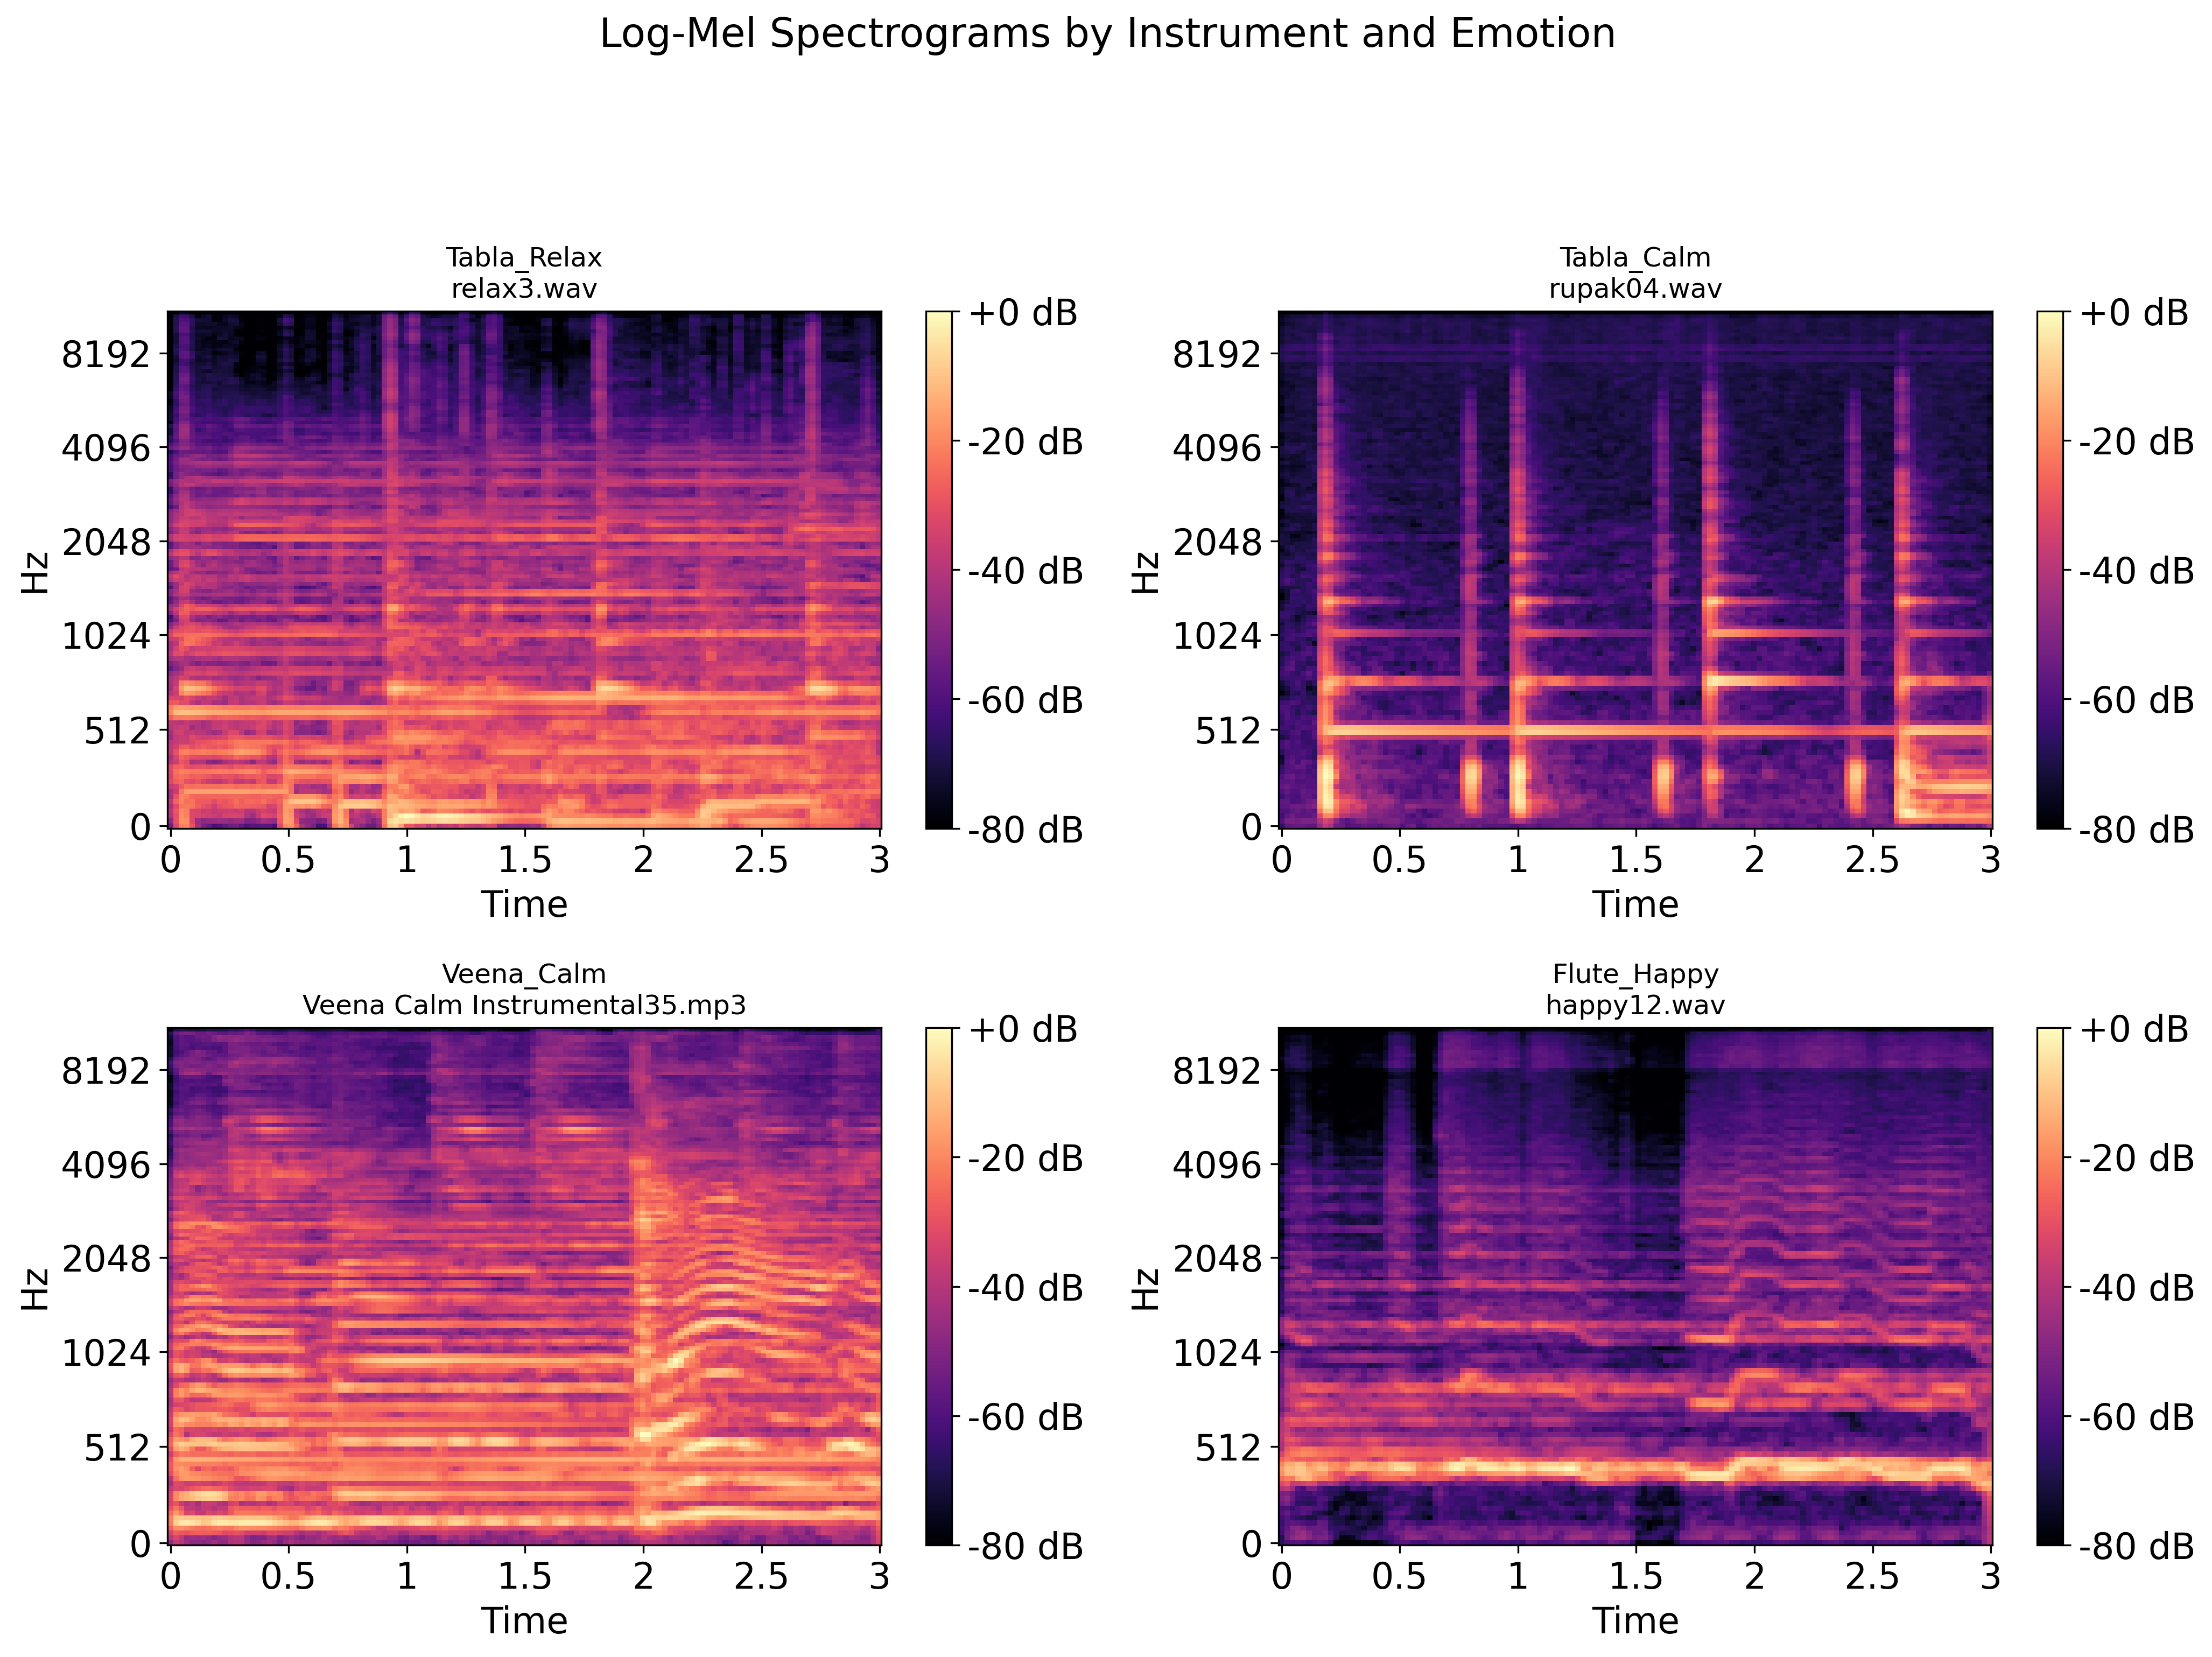

In [19]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import os
import random

# Define how many samples to show
num_samples = 4  # total spectrograms to display
rows, cols = 2, 2  # grid layout

# Collect all valid audio files with full path
all_audio_files = [
    os.path.join(root, file)
    for root, _, files in os.walk(data_path)
    for file in files if file.endswith(('.wav', '.mp3'))
]

# Shuffle and sample
random.shuffle(all_audio_files)
sampled_files = all_audio_files[:num_samples]

# Set global font size
plt.rcParams.update({'font.size': 16})

# Plot spectrograms
fig = plt.figure(figsize=(14, 10), dpi=300)  # Adjusted size for 2x2
for idx, file_path in enumerate(sampled_files):
    # Extract labels from path
    parts = file_path.split('/')
    instrument = parts[-3]
    emotion = parts[-2]
    file_name = os.path.basename(file_path)

    # Load and process audio
    y, sr = librosa.load(file_path, sr=22050, duration=3)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    log_S = librosa.power_to_db(S, ref=np.max)

    # Plot
    plt.subplot(rows, cols, idx + 1)
    librosa.display.specshow(log_S, sr=sr, x_axis='time', y_axis='mel', cmap='magma')
    plt.title(f"{instrument}_{emotion}\n{file_name}", fontsize=12)
    plt.colorbar(format='%+2.0f dB')
    plt.tight_layout()

# Super title
plt.suptitle("Log-Mel Spectrograms by Instrument and Emotion", fontsize=18, y=1.03)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


/tmp/ipykernel_36/389104601.py:47: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_36/389104601.py:54: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


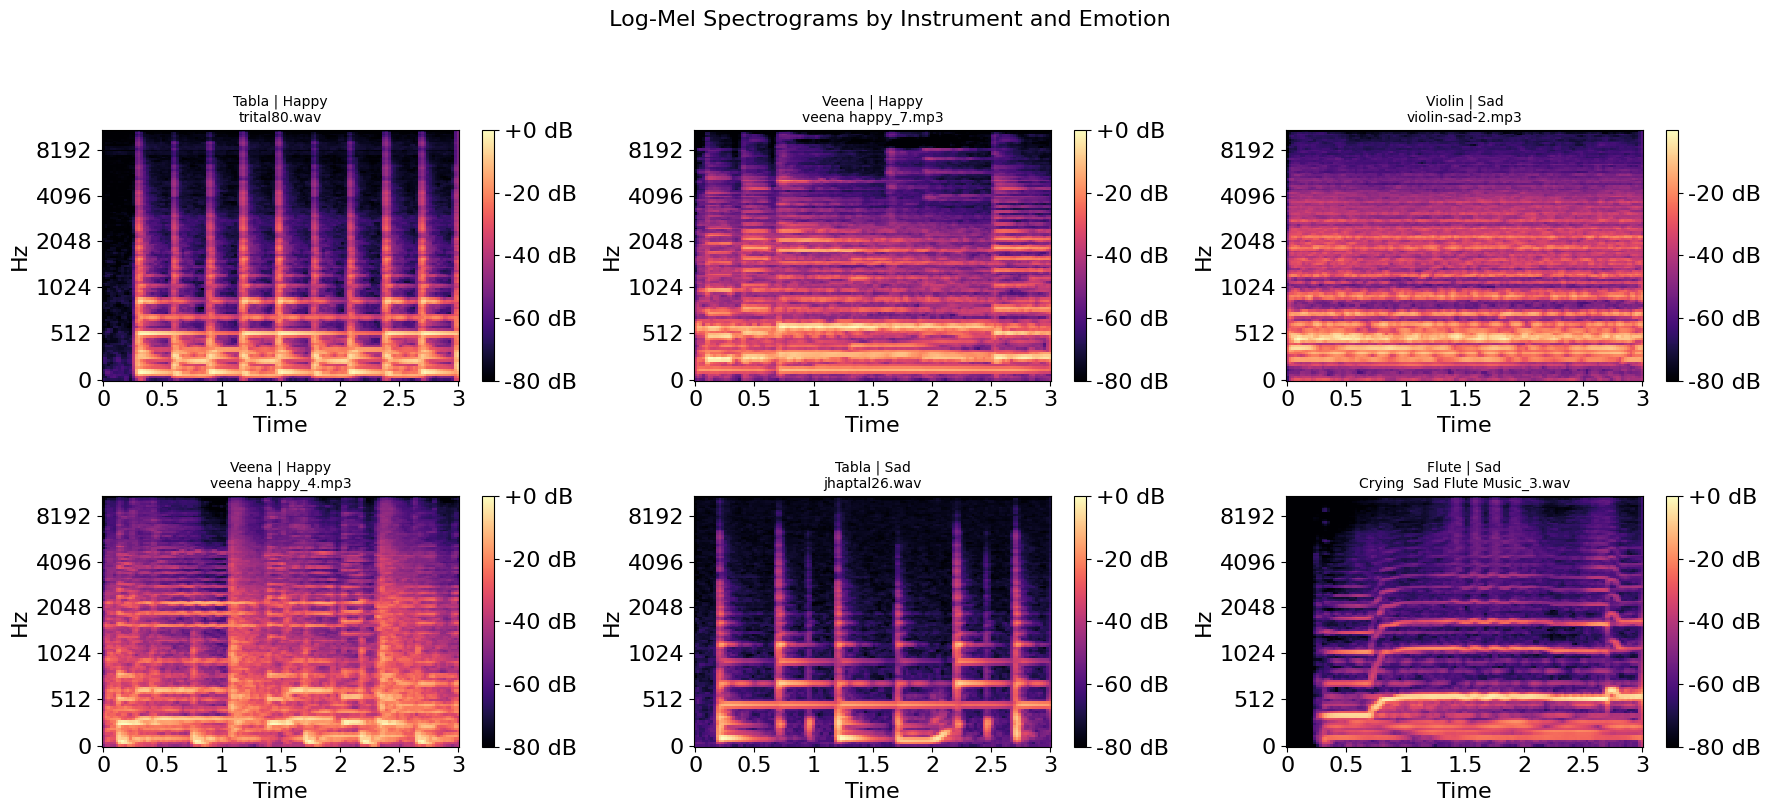

In [20]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import os
import random

# 📁 Dataset path
data_path = '/kaggle/input/indian-classical-instrument-music-emotion-dataset/Indian Classical Instrument Music Emotion Dataset'

# 🎯 Number of random samples to display
num_samples = 6  # Can change to 4, 8, etc.
rows, cols = 2, 3  # Grid layout

#  Collect all valid audio file paths
all_audio_files = [
    os.path.join(root, file)
    for root, _, files in os.walk(data_path)
    for file in files if file.endswith(('.wav', '.mp3'))
]

#  Shuffle and sample
random.shuffle(all_audio_files)
sampled_files = all_audio_files[:num_samples]

#  Create subplots
plt.figure(figsize=(18, 8))
for idx, file_path in enumerate(sampled_files):
    try:
        #  Extract instrument and emotion
        parts = file_path.split('/')
        instrument = parts[-3]
        emotion = parts[-2]
        file_name = os.path.basename(file_path)

        #  Load audio
        y, sr = librosa.load(file_path, sr=22050, duration=3)

        #  Compute log-Mel spectrogram
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        log_S = librosa.power_to_db(S, ref=np.max)

        #  Plot each subplot
        plt.subplot(rows, cols, idx + 1)
        librosa.display.specshow(log_S, sr=sr, x_axis='time', y_axis='mel', cmap='magma')
        plt.title(f"{instrument} | {emotion}\n{file_name}", fontsize=10)
        plt.colorbar(format='%+2.0f dB')
        plt.tight_layout()

    except Exception as e:
        print(f" Error with {file_path}: {e}")

#  Global title
plt.suptitle(" Log-Mel Spectrograms by Instrument and Emotion", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import numpy as np

# Step 1: Convert labels back to string list (if not already)
y = np.array(y_label_list)  # restore original string labels

# Step 2: Split y into instrument and emotion
instruments = [label.split('_')[0] for label in y]
emotions = [label.split('_')[1] for label in y]

# Step 3: Label encode + one-hot for instrument
le_instr = LabelEncoder()
y_instr = to_categorical(le_instr.fit_transform(instruments))

# Step 4: Label encode + one-hot for emotion
le_emo = LabelEncoder()
y_emotion = to_categorical(le_emo.fit_transform(emotions))

# Step 5: Reshape X (ensure it’s ready for CNN)
X = np.array(X_mel_list)  # if not already set
X = X.reshape(-1, 128, 128, 1)

# Step 6: Train-test split
X_train, X_test, y_emotion_train, y_emotion_test, y_instr_train, y_instr_test = train_test_split(
    X, y_emotion, y_instr, test_size=0.2, random_state=42, stratify=y
)

#  Show status
print(" X_train shape:", X_train.shape)
print(" y_emotion_train shape:", y_emotion_train.shape)
print(" y_instr_train shape:", y_instr_train.shape)
print(" Classes (Emotions):", le_emo.classes_)
print(" Classes (Instruments):", le_instr.classes_)


 X_train shape: (602, 128, 128, 1)
 y_emotion_train shape: (602, 4)
 y_instr_train shape: (602, 4)
 Classes (Emotions): ['Calm' 'Happy' 'Relax' 'Sad']
 Classes (Instruments): ['Flute' 'Tabla' 'Veena' 'Violin']


In [22]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Concatenate, Reshape, Dense, Dropout, Bidirectional, GRU,
    MultiHeadAttention, GlobalAveragePooling1D
)
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam

# Custom layer to expand 1-channel spectrogram to 3 channels (for VGG16 compatibility)
def expand_to_rgb(x):
    return Concatenate()([x, x, x])  # Shape: (128, 128, 1) → (128, 128, 3)

# Input shape
input_shape = (128, 128, 1)
inputs = Input(shape=input_shape)

# Expand to 3-channel RGB
x = expand_to_rgb(inputs)

# Load VGG16 base
musicnet = VGG16(include_top=False, weights='imagenet', input_shape=(128, 128, 3))
musicnet.trainable = False  # Freeze feature extractor
x = musicnet(x)  # Output shape: (4, 4, 512)

# Reshape CNN output for temporal modeling
x = Reshape((x.shape[1] * x.shape[2], x.shape[3]))(x)  # Shape: (16, 512)

# Bi-GRU
x = Bidirectional(GRU(64, return_sequences=True))(x)  # Output: (16, 128)
x = Dropout(0.3)(x)

#  Multi-Head Self-Attention Layer
attention_out = MultiHeadAttention(num_heads=4, key_dim=64)(x, x)  # Shape: (16, 128)
x = GlobalAveragePooling1D()(attention_out)  # Shape: (128,)

# Dual classification heads
emotion_output = Dense(4, activation='softmax', name='emotion_output')(x)
instrument_output = Dense(4, activation='softmax', name='instrument_output')(x)

# Build model
swaranet = Model(inputs=inputs, outputs=[emotion_output, instrument_output], name="SwaraNet")

# Compile model
swaranet.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss={'emotion_output': 'categorical_crossentropy', 'instrument_output': 'categorical_crossentropy'},
    metrics={'emotion_output': 'accuracy', 'instrument_output': 'accuracy'}
)

# Print architecture
swaranet.summary()


I0000 00:00:1760433633.113281      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "SwaraNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ input_layer[0][0… │
│ (Concatenate)       │ 3)                │            │ input_layer[0][0… │
│                     │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 4, 4, 512) │ 14,714,688 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 16, 512)   │          0 │ vgg16[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 16, 128)   │    221,952 │ reshape[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16, 128)   │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 16, 128)   │    131,968 │ dropout[0][0],    │
│ (MultiHeadAttentio… │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ multi_head_atten… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emotion_output      │ (None, 4)         │        516 │ global_average_p… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ instrument_output   │ (None, 4)         │        516 │ global_average_p… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,069,640 (57.49 MB)

 Trainable params: 354,952 (1.35 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [23]:
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

#  Define Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    verbose=1,
    min_lr=1e-6
)

#  Train the SwaraNet model
history = swaranet.fit(
    X_train,
    {'emotion_output': y_emotion_train, 'instrument_output': y_instr_train},
    validation_data=(X_test, {'emotion_output': y_emotion_test, 'instrument_output': y_instr_test}),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop, lr_reduce],
    verbose=1
)


Epoch 1/20


I0000 00:00:1760433641.289277     113 cuda_dnn.cc:529] Loaded cuDNN version 90300


19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 195ms/step - emotion_output_accuracy: 0.3367 - emotion_output_loss: 1.3516 - instrument_output_accuracy: 0.5114 - instrument_output_loss: 1.1316 - loss: 2.4836 - val_emotion_output_accuracy: 0.4305 - val_emotion_output_loss: 1.1515 - val_instrument_output_accuracy: 0.8344 - val_instrument_output_loss: 0.4926 - val_loss: 1.6577 - learning_rate: 5.0000e-04
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - emotion_output_accuracy: 0.5485 - emotion_output_loss: 1.0757 - instrument_output_accuracy: 0.8997 - instrument_output_loss: 0.3861 - loss: 1.4619 - val_emotion_output_accuracy: 0.6358 - val_emotion_output_loss: 0.8465 - val_instrument_output_accuracy: 0.9272 - val_instrument_output_loss: 0.2532 - val_loss: 1.1062 - learning_rate: 5.0000e-04
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - emotion_output_accuracy: 0.7601 - emotion_output_loss: 0.6901 - instrument_output_accuracy: 0.9510 - instrument_output_loss: 0.1764 - loss: 0.8667 - val_emotion_o

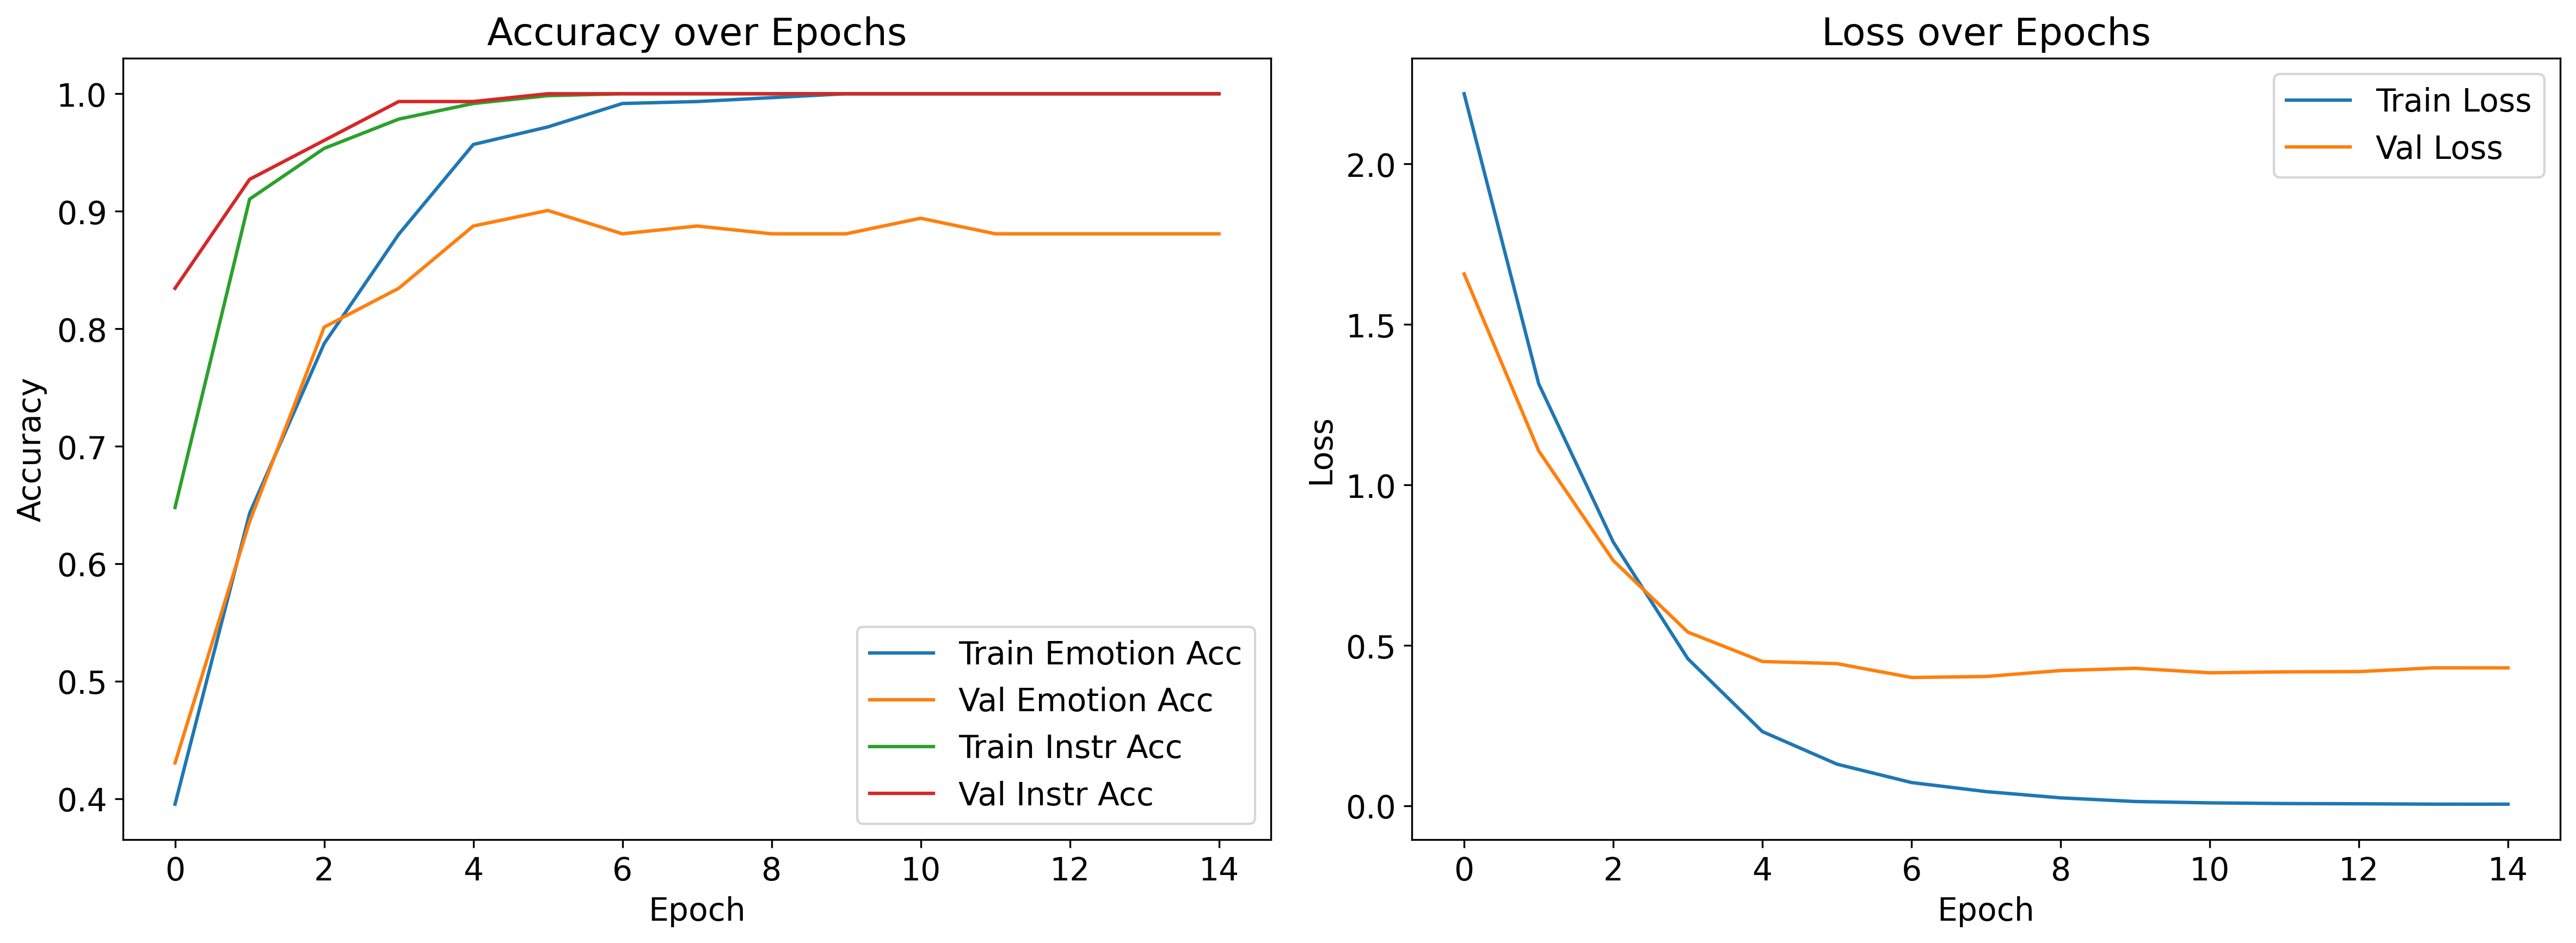

In [24]:
#  Plot training history
def plot_training_history(history):
    plt.rcParams.update({'font.size': 14})
    
    plt.figure(figsize=(16, 6), dpi=300)

    # Accuracy plots
    plt.subplot(1, 2, 1)
    plt.plot(history.history['emotion_output_accuracy'], label='Train Emotion Acc')
    plt.plot(history.history['val_emotion_output_accuracy'], label='Val Emotion Acc')
    plt.plot(history.history['instrument_output_accuracy'], label='Train Instr Acc')
    plt.plot(history.history['val_instrument_output_accuracy'], label='Val Instr Acc')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss plots
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

#  Show accuracy/loss graphs
plot_training_history(history)


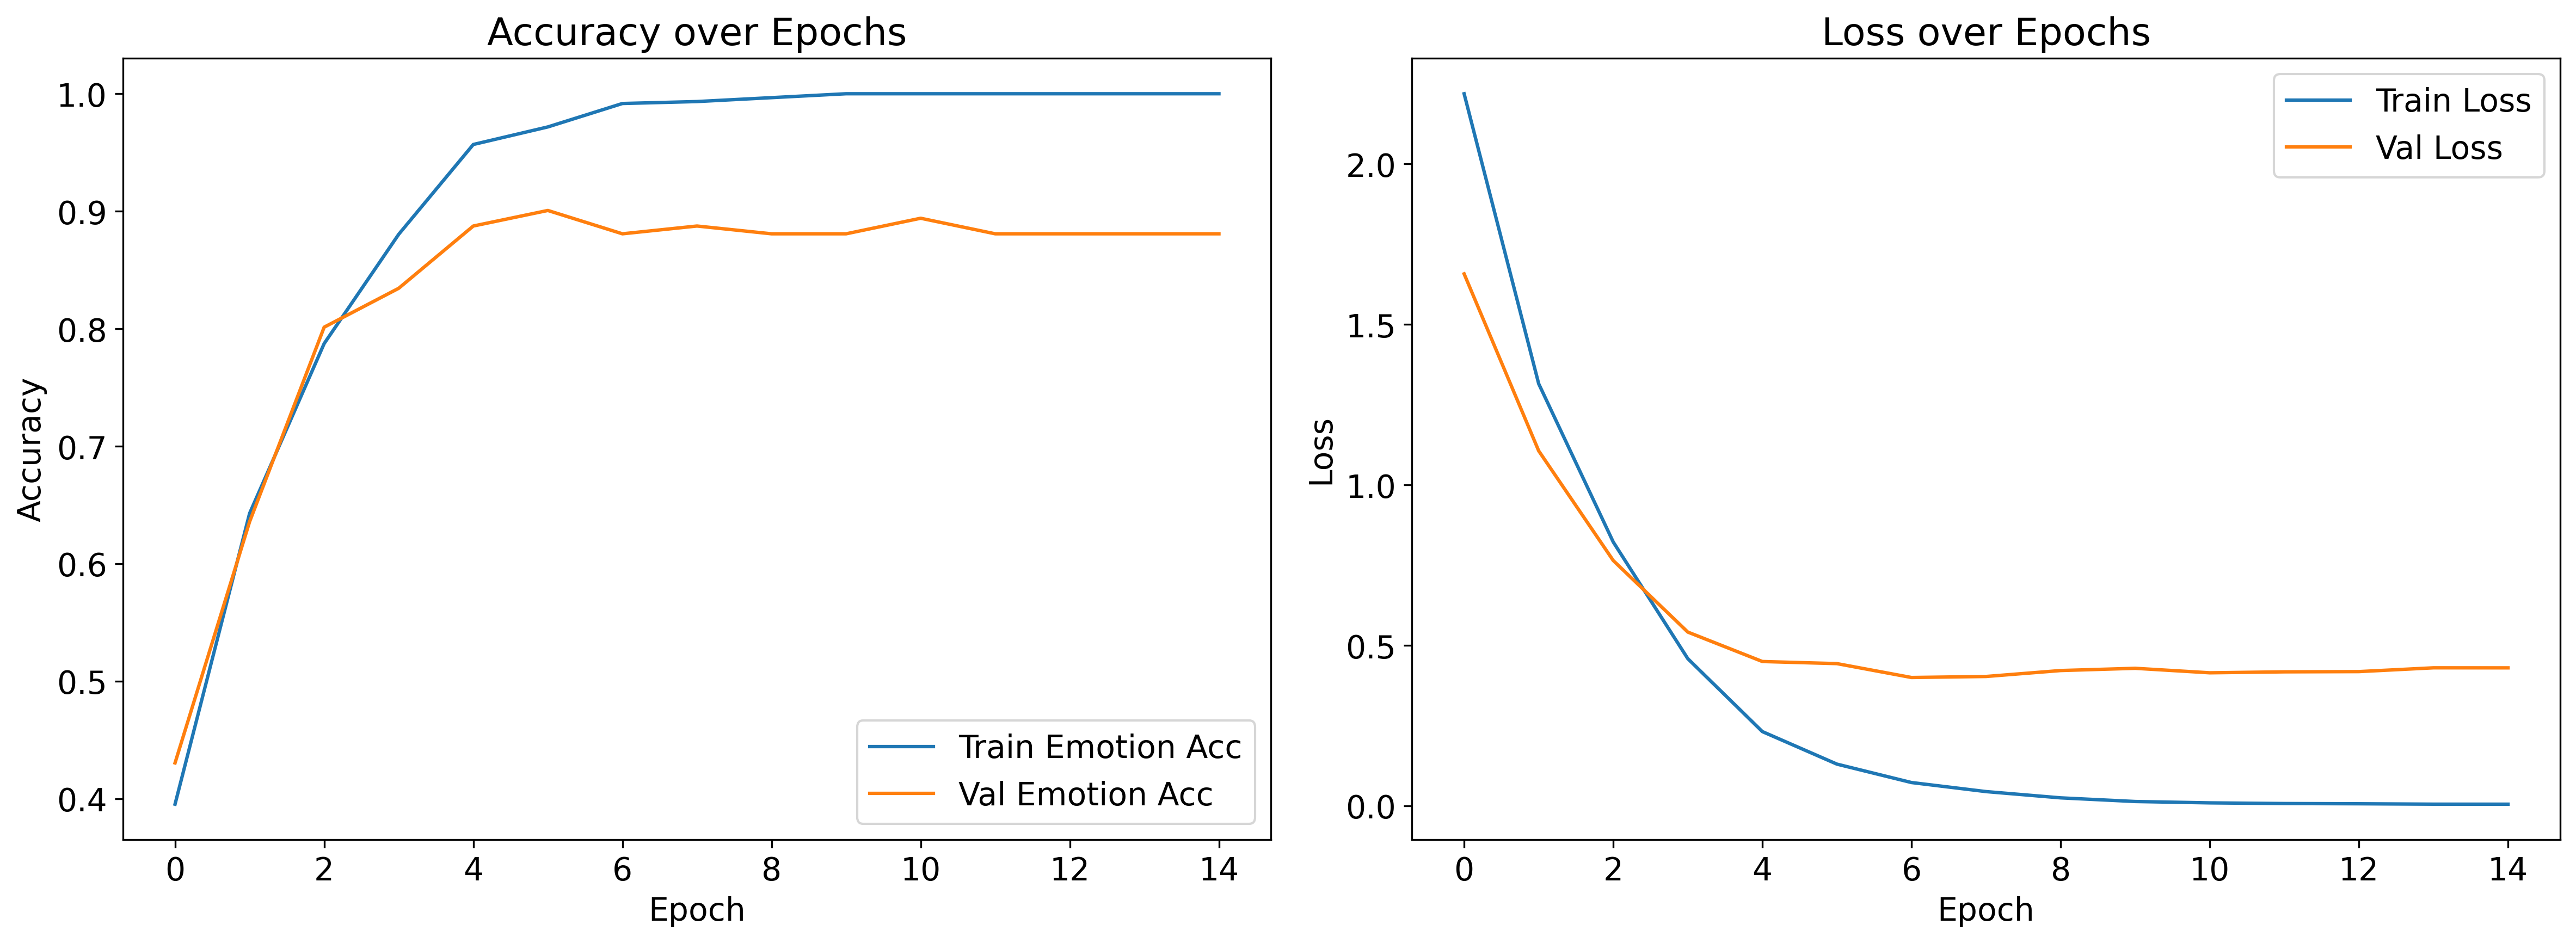

In [25]:
#  Plot training history
def plot_training_history(history):
    plt.rcParams.update({'font.size': 14})
    
    plt.figure(figsize=(16, 6), dpi=300)

    # Accuracy plots
    plt.subplot(1, 2, 1)
    plt.plot(history.history['emotion_output_accuracy'], label='Train Emotion Acc')
    plt.plot(history.history['val_emotion_output_accuracy'], label='Val Emotion Acc')
    
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss plots
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

#  Show accuracy/loss graphs
plot_training_history(history)


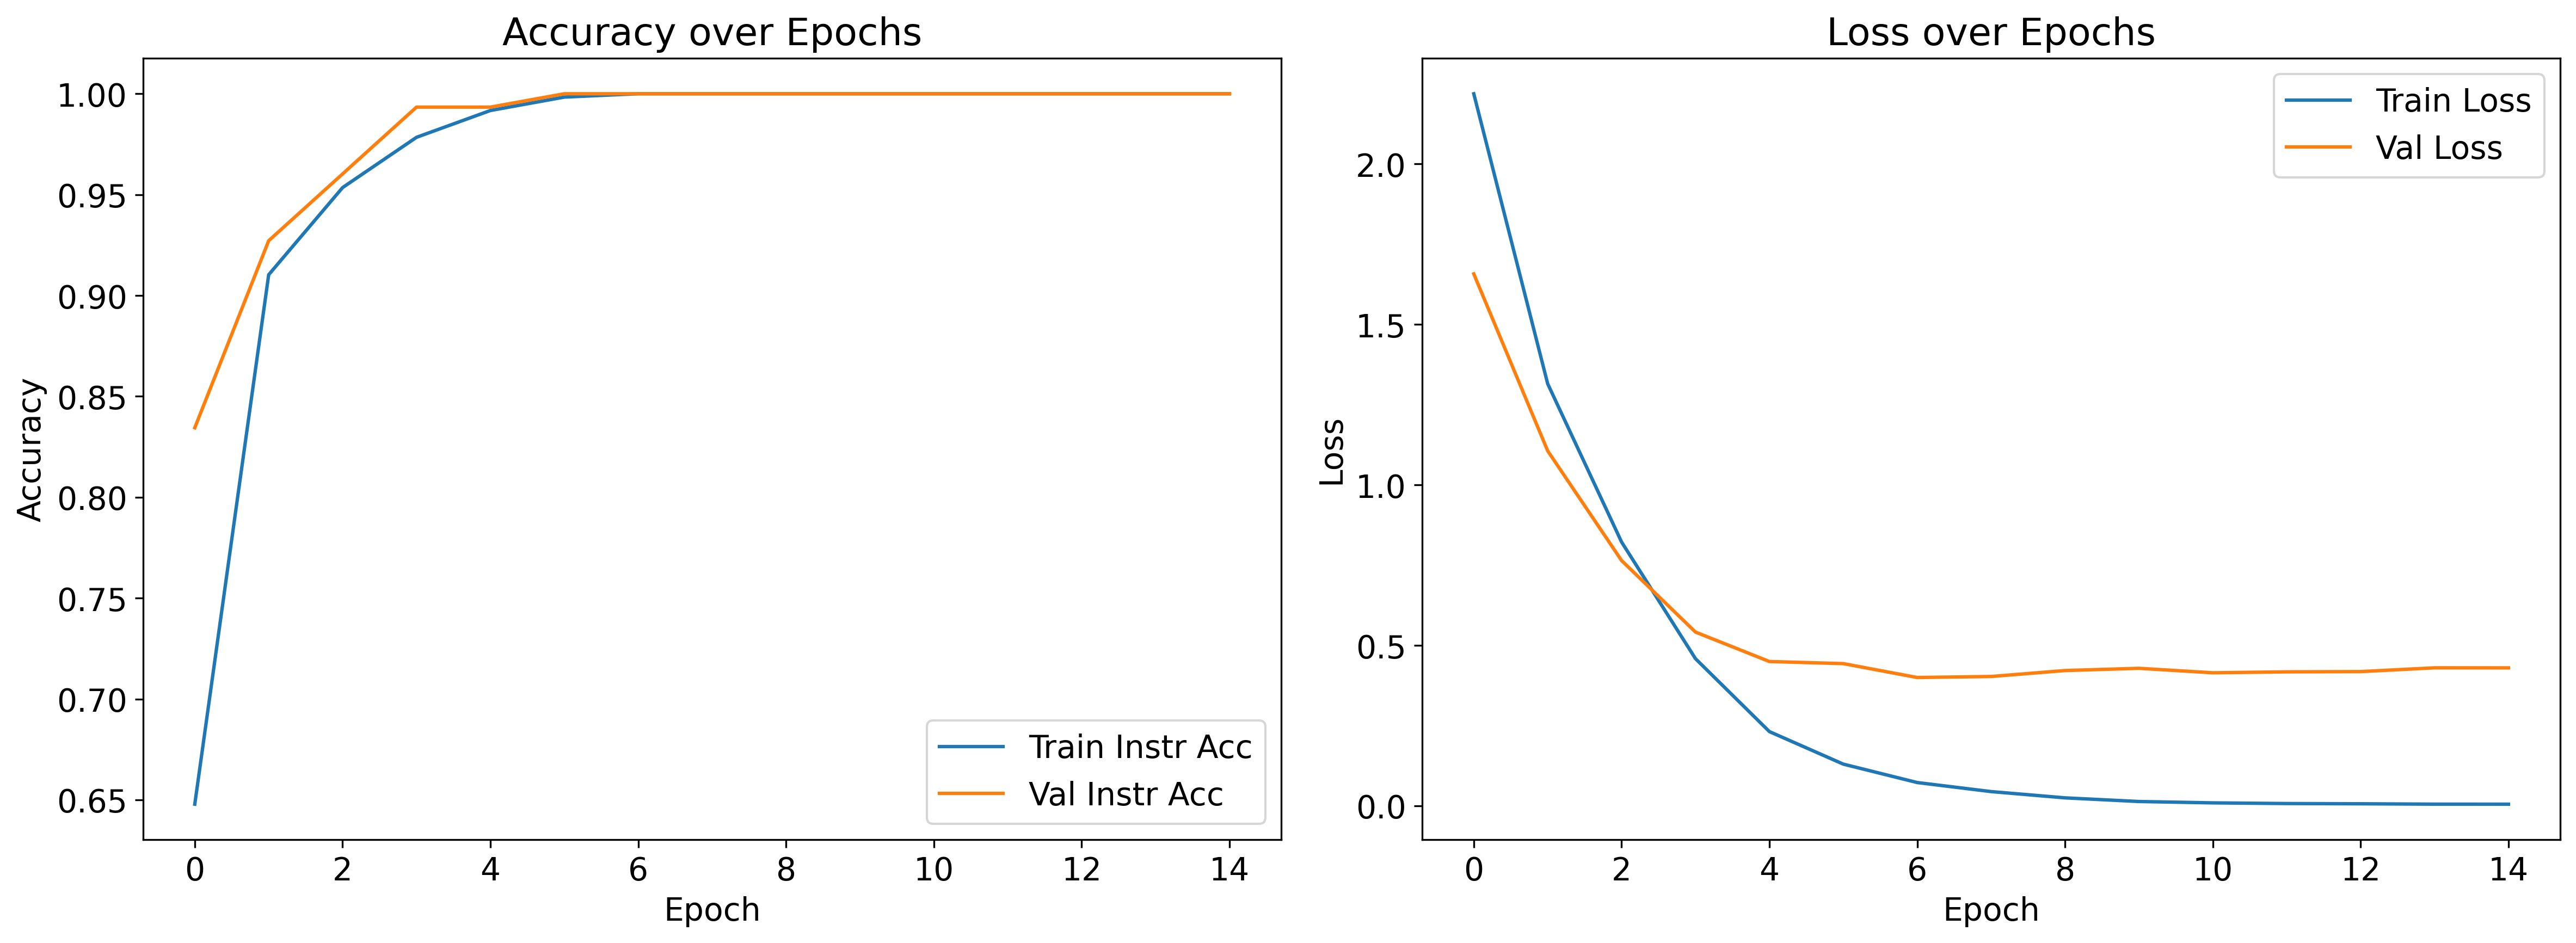

In [26]:
#  Plot training history
def plot_training_history(history):
    plt.rcParams.update({'font.size': 14})
    
    plt.figure(figsize=(16, 6), dpi=300)

    # Accuracy plots
    plt.subplot(1, 2, 1)
    
    plt.plot(history.history['instrument_output_accuracy'], label='Train Instr Acc')
    plt.plot(history.history['val_instrument_output_accuracy'], label='Val Instr Acc')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss plots
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

#  Show accuracy/loss graphs
plot_training_history(history)


In [27]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

#  Predict on test set
y_pred = swaranet.predict(X_test)

#  Convert one-hot to class labels
y_emotion_true = np.argmax(y_emotion_test, axis=1)
y_instr_true = np.argmax(y_instr_test, axis=1)

y_emotion_pred = np.argmax(y_pred[0], axis=1)
y_instr_pred = np.argmax(y_pred[1], axis=1)

#  Print classification reports for each output
print(" Emotion Output Metrics:")
print(classification_report(y_emotion_true, y_emotion_pred, digits=4))

print(" Instrument Output Metrics:")
print(classification_report(y_instr_true, y_instr_pred, digits=4))

#  Overall Scores
emotion_acc = accuracy_score(y_emotion_true, y_emotion_pred)
instrument_acc = accuracy_score(y_instr_true, y_instr_pred)

emotion_precision = precision_score(y_emotion_true, y_emotion_pred, average='weighted')
instrument_precision = precision_score(y_instr_true, y_instr_pred, average='weighted')

emotion_recall = recall_score(y_emotion_true, y_emotion_pred, average='weighted')
instrument_recall = recall_score(y_instr_true, y_instr_pred, average='weighted')

emotion_f1 = f1_score(y_emotion_true, y_emotion_pred, average='weighted')
instrument_f1 = f1_score(y_instr_true, y_instr_pred, average='weighted')

#  Summary
print("\n SwaraNet Evaluation Summary:")
print(f"Emotion - Accuracy: {emotion_acc:.4f}, Precision: {emotion_precision:.4f}, Recall: {emotion_recall:.4f}, F1 Score: {emotion_f1:.4f}")
print(f"Instrument - Accuracy: {instrument_acc:.4f}, Precision: {instrument_precision:.4f}, Recall: {instrument_recall:.4f}, F1 Score: {instrument_f1:.4f}")


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step
 Emotion Output Metrics:
              precision    recall  f1-score   support

           0     0.7949    0.8611    0.8267        36
           1     0.9762    0.9535    0.9647        43
           2     0.8378    0.8611    0.8493        36
           3     0.9091    0.8333    0.8696        36

    accuracy                         0.8808       151
   macro avg     0.8795    0.8773    0.8776       151
weighted avg     0.8840    0.8808    0.8816       151

 Instrument Output Metrics:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        21
           1     1.0000    1.0000    1.0000        48
           2     1.0000    1.0000    1.0000        42
           3     1.0000    1.0000    1.0000        40

    accuracy                         1.0000       151
   macro avg     1.0000    1.0000    1.0000       151
weighted avg     1.0000    1.0000    1.0000       151


 SwaraNet Evaluation Summary:
Emotion

In [28]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

#  Predict on test set
y_pred = swaranet.predict(X_test)

#  Convert one-hot to class labels
y_emotion_true = np.argmax(y_emotion_test, axis=1)
y_instr_true = np.argmax(y_instr_test, axis=1)

y_emotion_pred = np.argmax(y_pred[0], axis=1)
y_instr_pred = np.argmax(y_pred[1], axis=1)

#  Class labels
emotion_labels = ['Calm', 'Happy', 'Relax', 'Sad']
instrument_labels = ['Flute', 'Tabla', 'Veena', 'Violin']

#  Print classification reports with class names
print(" Emotion Output Metrics:")
print(classification_report(y_emotion_true, y_emotion_pred, target_names=emotion_labels, digits=4))

print(" Instrument Output Metrics:")
print(classification_report(y_instr_true, y_instr_pred, target_names=instrument_labels, digits=4))

#  Overall Scores
emotion_acc = accuracy_score(y_emotion_true, y_emotion_pred)
instrument_acc = accuracy_score(y_instr_true, y_instr_pred)

emotion_precision = precision_score(y_emotion_true, y_emotion_pred, average='weighted')
instrument_precision = precision_score(y_instr_true, y_instr_pred, average='weighted')

emotion_recall = recall_score(y_emotion_true, y_emotion_pred, average='weighted')
instrument_recall = recall_score(y_instr_true, y_instr_pred, average='weighted')

emotion_f1 = f1_score(y_emotion_true, y_emotion_pred, average='weighted')
instrument_f1 = f1_score(y_instr_true, y_instr_pred, average='weighted')

#  Summary
print("\n SwaraNet Evaluation Summary:")
print(f"Emotion - Accuracy: {emotion_acc:.4f}, Precision: {emotion_precision:.4f}, Recall: {emotion_recall:.4f}, F1 Score: {emotion_f1:.4f}")
print(f"Instrument - Accuracy: {instrument_acc:.4f}, Precision: {instrument_precision:.4f}, Recall: {instrument_recall:.4f}, F1 Score: {instrument_f1:.4f}")


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
 Emotion Output Metrics:
              precision    recall  f1-score   support

        Calm     0.7949    0.8611    0.8267        36
       Happy     0.9762    0.9535    0.9647        43
       Relax     0.8378    0.8611    0.8493        36
         Sad     0.9091    0.8333    0.8696        36

    accuracy                         0.8808       151
   macro avg     0.8795    0.8773    0.8776       151
weighted avg     0.8840    0.8808    0.8816       151

 Instrument Output Metrics:
              precision    recall  f1-score   support

       Flute     1.0000    1.0000    1.0000        21
       Tabla     1.0000    1.0000    1.0000        48
       Veena     1.0000    1.0000    1.0000        42
      Violin     1.0000    1.0000    1.0000        40

    accuracy                         1.0000       151
   macro avg     1.0000    1.0000    1.0000       151
weighted avg     1.0000    1.0000    1.0000       151


 SwaraNet Evaluation Summary:
Emotion 

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
 Classification Report - Instruments:
              precision    recall  f1-score   support

       Flute       1.00      1.00      1.00        21
       Tabla       1.00      1.00      1.00        48
       Veena       1.00      1.00      1.00        42
      Violin       1.00      1.00      1.00        40

    accuracy                           1.00       151
   macro avg       1.00      1.00      1.00       151
weighted avg       1.00      1.00      1.00       151


 Classification Report - Emotions:
              precision    recall  f1-score   support

        Calm       0.79      0.86      0.83        36
       Happy       0.98      0.95      0.96        43
       Relax       0.84      0.86      0.85        36
         Sad       0.91      0.83      0.87        36

    accuracy                           0.88       151
   macro avg       0.88      0.88      0.88       151
weighted avg       0.88      0.88      0.88       151



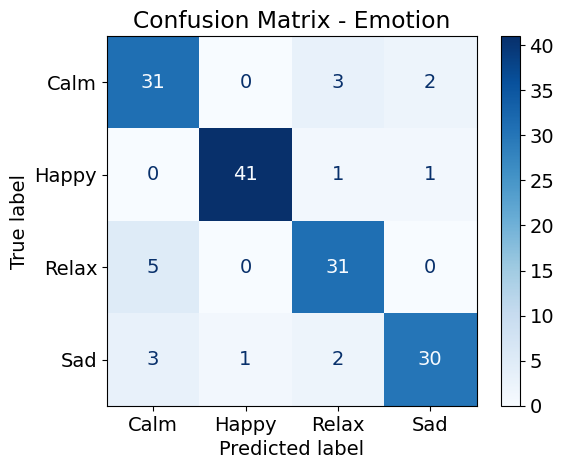

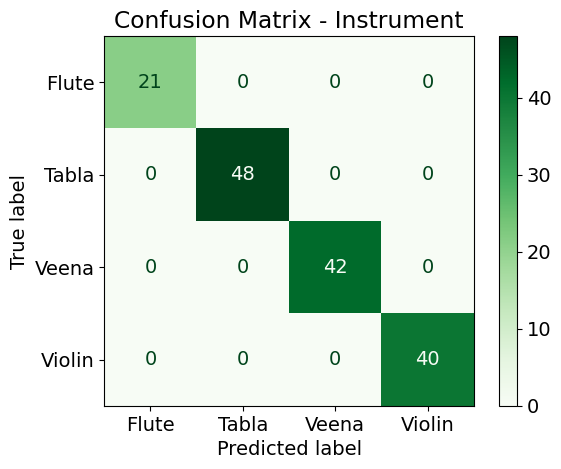


 Per-Instrument Confusion Matrices for Emotion:

 Instrument: Flute


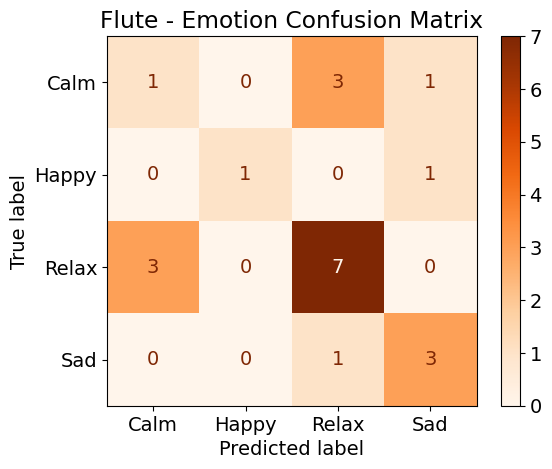


 Instrument: Tabla


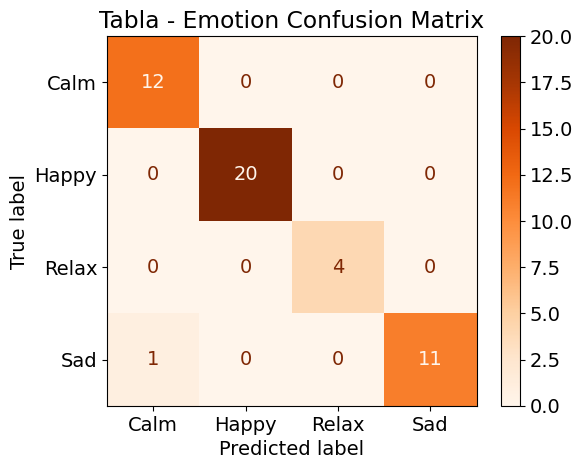


 Instrument: Veena


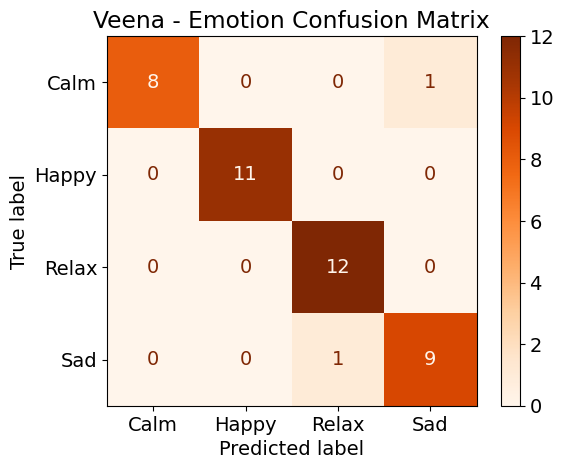


 Instrument: Violin


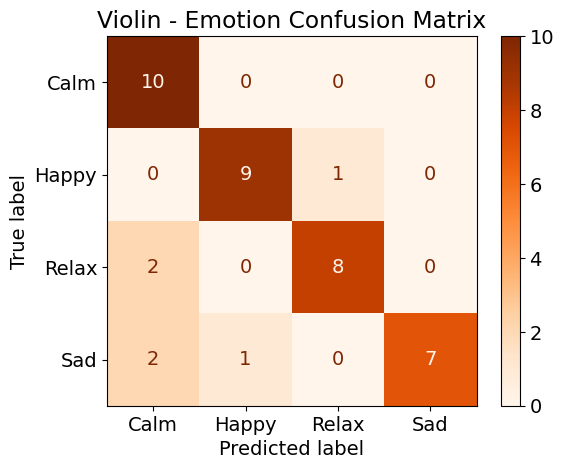

In [29]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Predict on test data
y_emotion_pred_probs, y_instr_pred_probs = swaranet.predict(X_test)

# Convert softmax outputs to class labels
y_emotion_pred = np.argmax(y_emotion_pred_probs, axis=1)
y_instr_pred = np.argmax(y_instr_pred_probs, axis=1)

y_emotion_true = np.argmax(y_emotion_test, axis=1)
y_instr_true = np.argmax(y_instr_test, axis=1)

#  Define class label names
emotion_labels = ['Calm', 'Happy', 'Relax', 'Sad']
instrument_labels = ['Flute', 'Tabla', 'Veena', 'Violin']  # match your encoding

#  Classification reports
print(" Classification Report - Instruments:")
print(classification_report(y_instr_true, y_instr_pred, target_names=instrument_labels))

print("\n Classification Report - Emotions:")
print(classification_report(y_emotion_true, y_emotion_pred, target_names=emotion_labels))

#  Confusion Matrix - Emotion
cm_emo = confusion_matrix(y_emotion_true, y_emotion_pred)
disp_emo = ConfusionMatrixDisplay(confusion_matrix=cm_emo, display_labels=emotion_labels)
disp_emo.plot(cmap='Blues')
plt.title("Confusion Matrix - Emotion")
plt.show()

# ✅ Confusion Matrix - Instrument
cm_instr = confusion_matrix(y_instr_true, y_instr_pred)
disp_instr = ConfusionMatrixDisplay(confusion_matrix=cm_instr, display_labels=instrument_labels)
disp_instr.plot(cmap='Greens')
plt.title("Confusion Matrix - Instrument")
plt.show()

# ✅ Per-Instrument Emotion Confusion Matrices
print("\n Per-Instrument Confusion Matrices for Emotion:")
for idx, instr_name in enumerate(instrument_labels):
    instr_indices = np.where(y_instr_true == idx)[0]
    y_emo_true_sub = y_emotion_true[instr_indices]
    y_emo_pred_sub = y_emotion_pred[instr_indices]

    cm_sub = confusion_matrix(y_emo_true_sub, y_emo_pred_sub)
    disp_sub = ConfusionMatrixDisplay(confusion_matrix=cm_sub, display_labels=emotion_labels)
    
    print(f"\n Instrument: {instr_name}")
    disp_sub.plot(cmap='Oranges')
    plt.title(f"{instr_name} - Emotion Confusion Matrix")
    plt.show()


In [30]:
import librosa
import numpy as np
from tensorflow.keras.utils import img_to_array
import tensorflow as tf

# Class labels
emotion_labels = ['Calm', 'Happy', 'Relax', 'Sad']
instrument_labels = ['Flute', 'Tabla', 'Veena', 'Violin']

# Preprocessing Function
def preprocess_audio(file_path, sr=22050, n_mels=128, duration=4):
    y, _ = librosa.load(file_path, sr=sr, duration=duration)
    if len(y) < sr * duration:
        y = np.pad(y, (0, sr * duration - len(y)))
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    
    # Normalize
    mel_spec_db -= mel_spec_db.min()
    mel_spec_db /= mel_spec_db.max()
    
    # Resize to 128x128 and expand dims
    mel_spec_db = tf.image.resize(mel_spec_db[..., np.newaxis], (128, 128)).numpy()
    mel_spec_db = np.expand_dims(mel_spec_db, axis=0)  # Shape: (1, 128, 128, 1)
    return mel_spec_db

#  Prediction Function
def predict_audio(file_path):
    print(f" Predicting: {file_path}")
    input_data = preprocess_audio(file_path)

    # Get predictions
    y_emotion_pred, y_instr_pred = swaranet.predict(input_data)

    # Get top-3 for each
    top3_emotions_idx = y_emotion_pred[0].argsort()[-3:][::-1]
    top3_instruments_idx = y_instr_pred[0].argsort()[-3:][::-1]

    print("\n Top-3 Instrument Predictions:")
    for idx in top3_instruments_idx:
        print(f"   {instrument_labels[idx]}: {100 * y_instr_pred[0][idx]:.2f}%")

    print("\n Top-3 Emotion Predictions:")
    for idx in top3_emotions_idx:
        print(f"   {emotion_labels[idx]}: {100 * y_emotion_pred[0][idx]:.2f}%")
    
    return file_path, y_emotion_pred, y_instr_pred


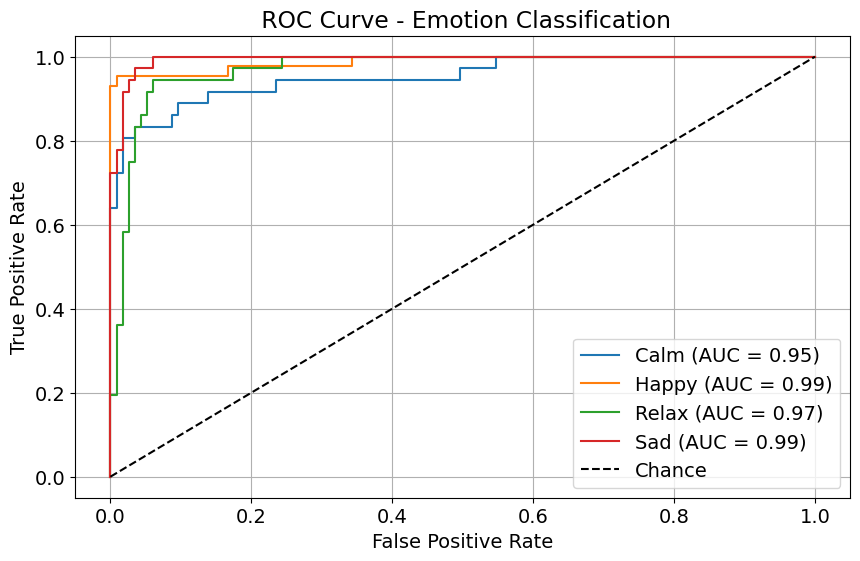

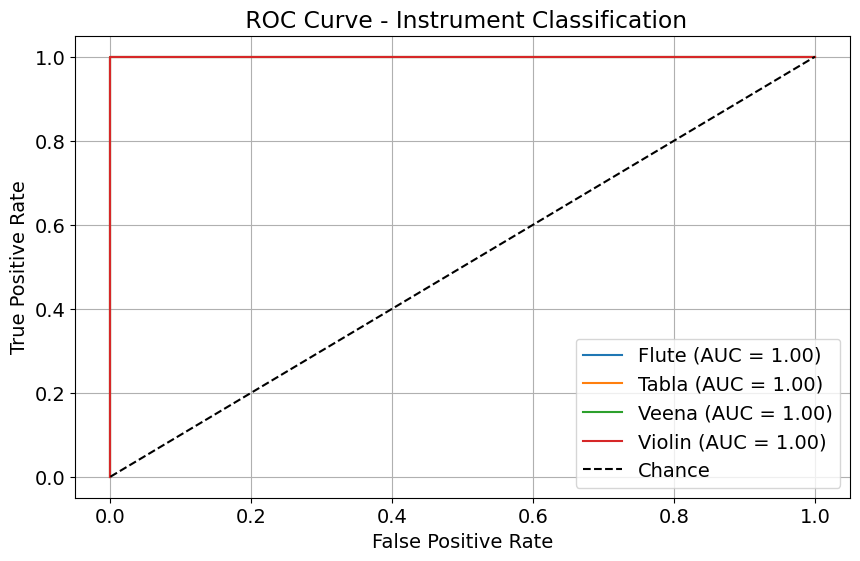

In [31]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Binarize the true labels for multi-class ROC
y_emotion_true_bin = label_binarize(np.argmax(y_emotion_test, axis=1), classes=[0, 1, 2, 3])
y_instr_true_bin = label_binarize(np.argmax(y_instr_test, axis=1), classes=[0, 1, 2, 3])

# Use softmax outputs directly for ROC
emotion_scores = y_emotion_pred_probs
instr_scores = y_instr_pred_probs

# Class label names
emotion_labels = ['Calm', 'Happy', 'Relax', 'Sad']
instrument_labels = ['Flute', 'Tabla', 'Veena', 'Violin']

# Plot ROC for Emotions
plt.figure(figsize=(10, 6))
for i in range(4):
    fpr, tpr, _ = roc_curve(y_emotion_true_bin[:, i], emotion_scores[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{emotion_labels[i]} (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Chance")
plt.title(" ROC Curve - Emotion Classification")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

# Plot ROC for Instruments
plt.figure(figsize=(10, 6))
for i in range(4):
    fpr, tpr, _ = roc_curve(y_instr_true_bin[:, i], instr_scores[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{instrument_labels[i]} (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Chance")
plt.title(" ROC Curve - Instrument Classification")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


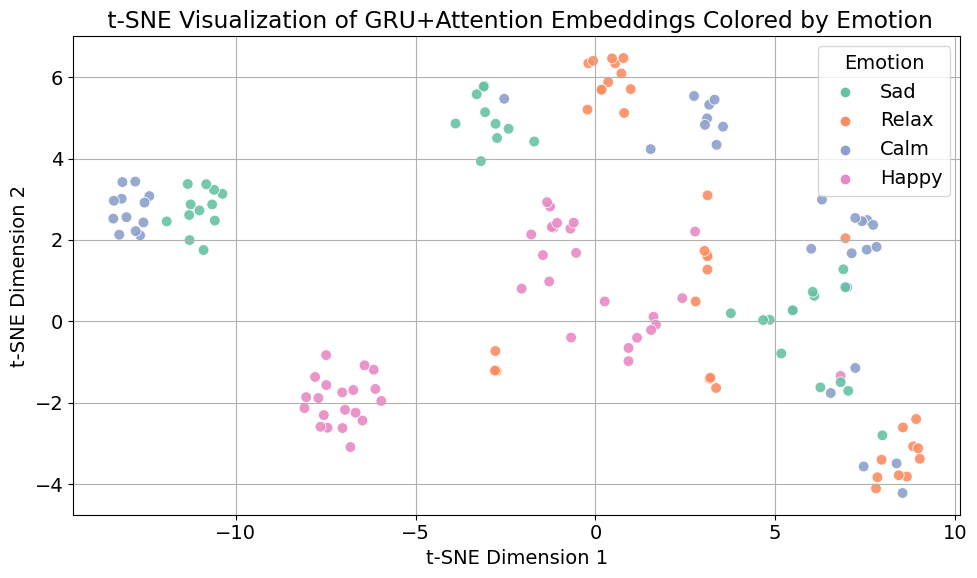

In [32]:
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling1D

# Emotion class labels
emotion_labels = ['Calm', 'Happy', 'Relax', 'Sad']

# Step 1: Extract GRU embeddings (3D output: (samples, time, features))
gru_output = swaranet.get_layer(index=-4).output  # Output of GRU (with return_sequences=True)
avg_pooled = GlobalAveragePooling1D()(gru_output)  # Now 2D: (samples, features)

# Step 2: Define new intermediate model
intermediate_model = Model(inputs=swaranet.input, outputs=avg_pooled)

# Step 3: Get 2D embeddings from X_test
gru_embeddings = intermediate_model.predict(X_test, verbose=0)

# Step 4: t-SNE transformation
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_result = tsne.fit_transform(gru_embeddings)

# Step 5: Map numeric emotion labels to text
emotion_true_indices = np.argmax(y_emotion_test, axis=1)
emotion_true_names = [emotion_labels[i] for i in emotion_true_indices]

# Step 6: Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=tsne_result[:, 0], 
    y=tsne_result[:, 1], 
    hue=emotion_true_names, 
    palette="Set2", 
    s=60,
    alpha=0.9
)
plt.title(" t-SNE Visualization of GRU+Attention Embeddings Colored by Emotion")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(title="Emotion")
plt.grid(True)
plt.tight_layout()
plt.show()


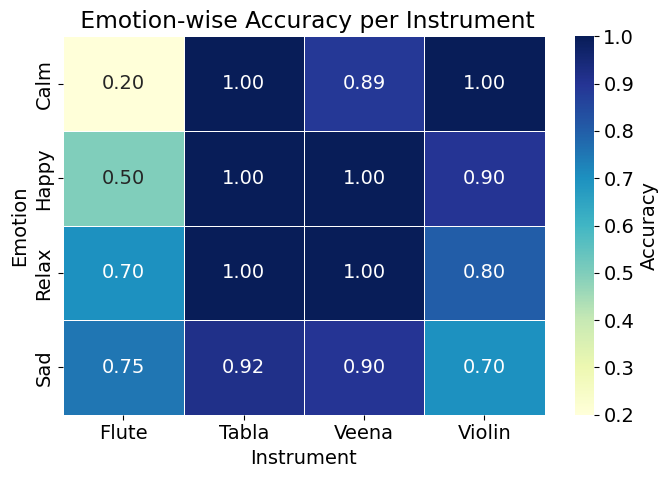

In [33]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Define class labels (update if your labels differ)
emotion_labels = ['Calm', 'Happy', 'Relax', 'Sad']
instrument_labels = ['Flute', 'Tabla', 'Veena', 'Violin']

# Step 1: Create accuracy matrix
heatmap_matrix = np.zeros((len(emotion_labels), len(instrument_labels)))  # shape: [emotion][instrument]

# Step 2: Compute per-emotion accuracy for each instrument
for instr in range(len(instrument_labels)):
    for emo in range(len(emotion_labels)):
        indices = np.where((y_instr_true == instr) & (y_emotion_true == emo))[0]
        if len(indices) > 0:
            correct = np.sum(y_emotion_pred[indices] == y_emotion_true[indices])
            acc = correct / len(indices)
        else:
            acc = 0
        heatmap_matrix[emo, instr] = acc

# Step 3: Plot
plt.figure(figsize=(7, 5))
sns.heatmap(
    heatmap_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="YlGnBu", 
    xticklabels=instrument_labels, 
    yticklabels=emotion_labels,
    linewidths=0.5, 
    cbar_kws={'label': 'Accuracy'}
)
plt.title(" Emotion-wise Accuracy per Instrument")
plt.xlabel("Instrument")
plt.ylabel("Emotion")
plt.tight_layout()
plt.show()


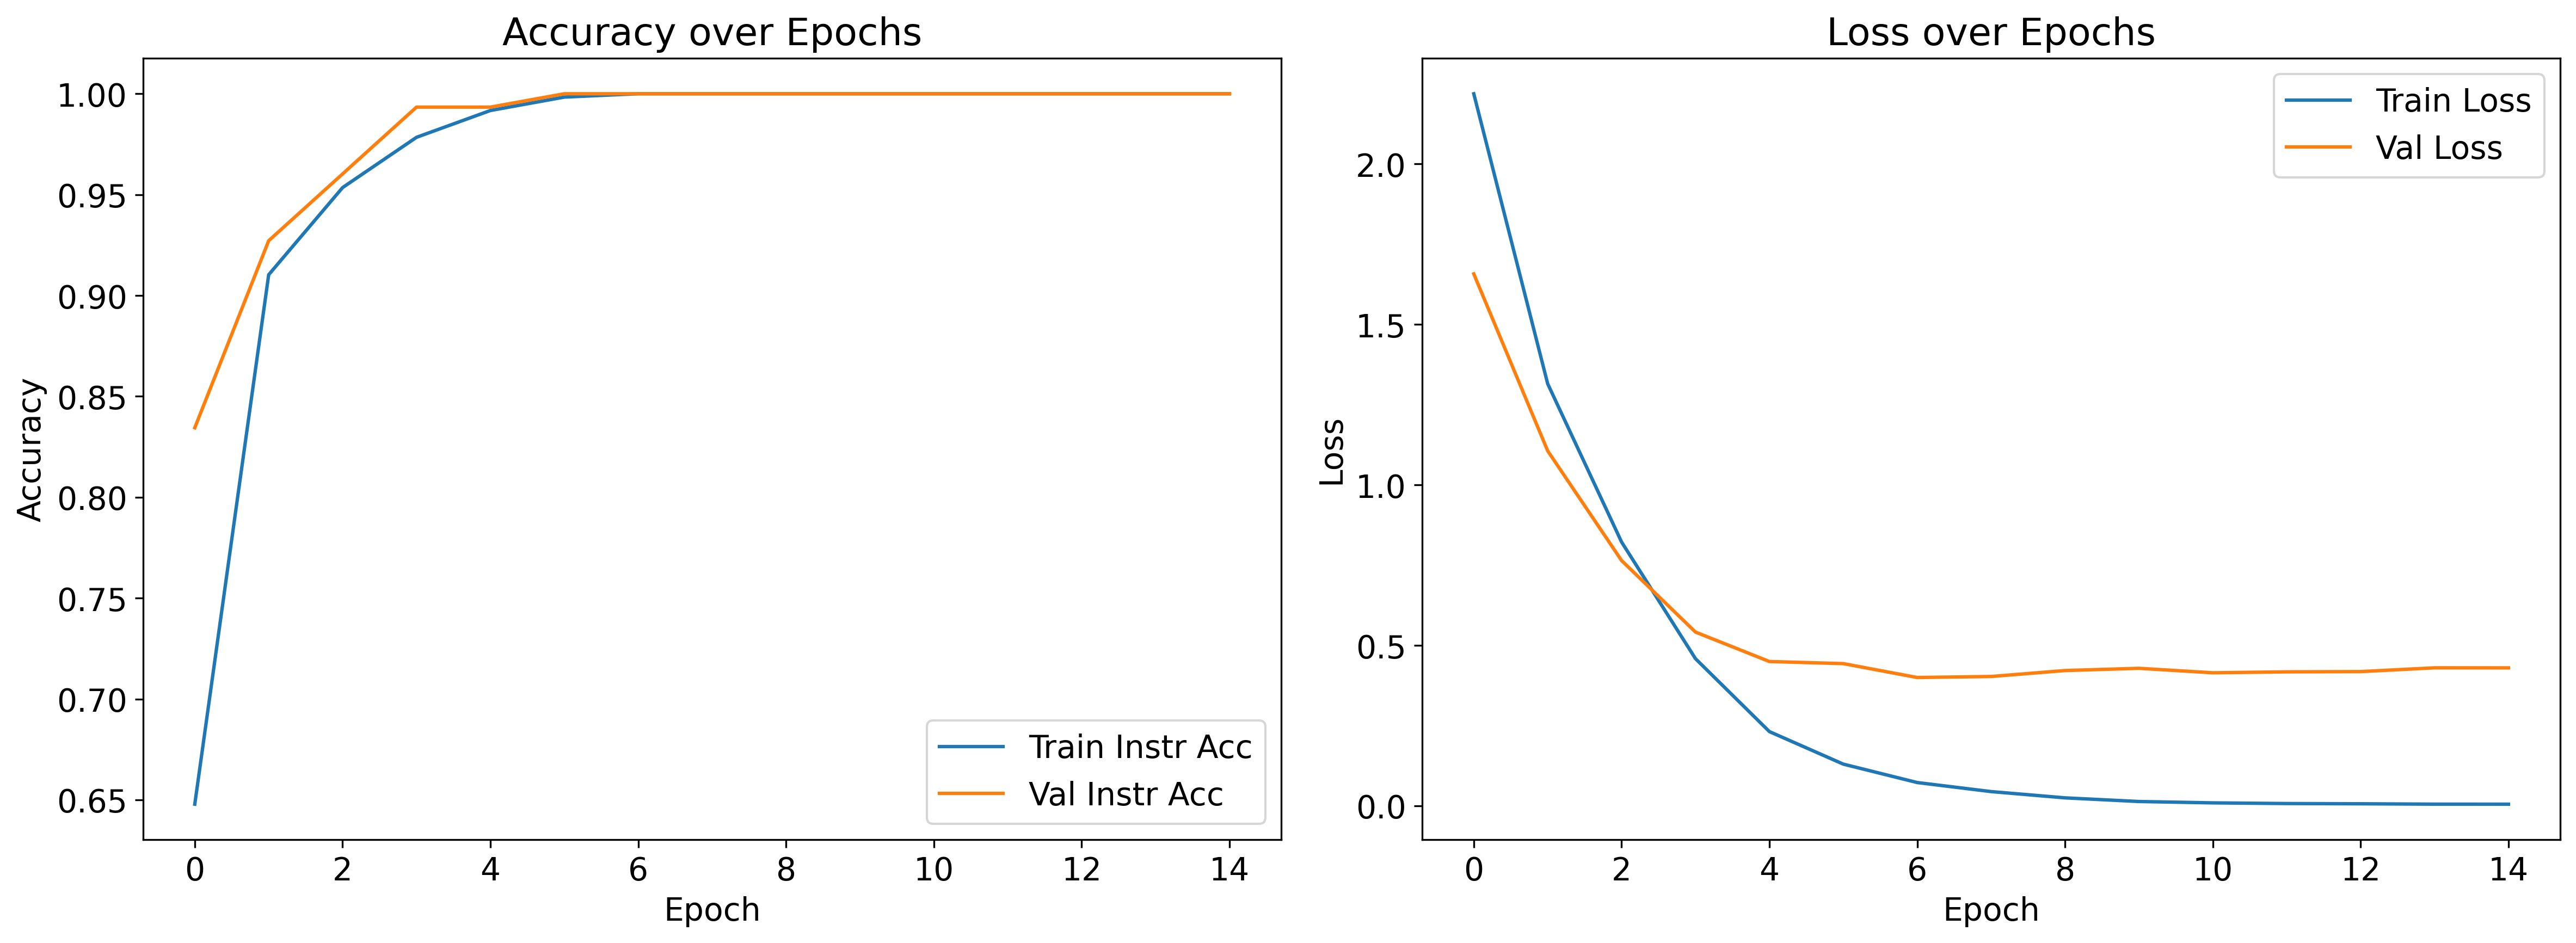

In [34]:
plot_training_history(history)

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


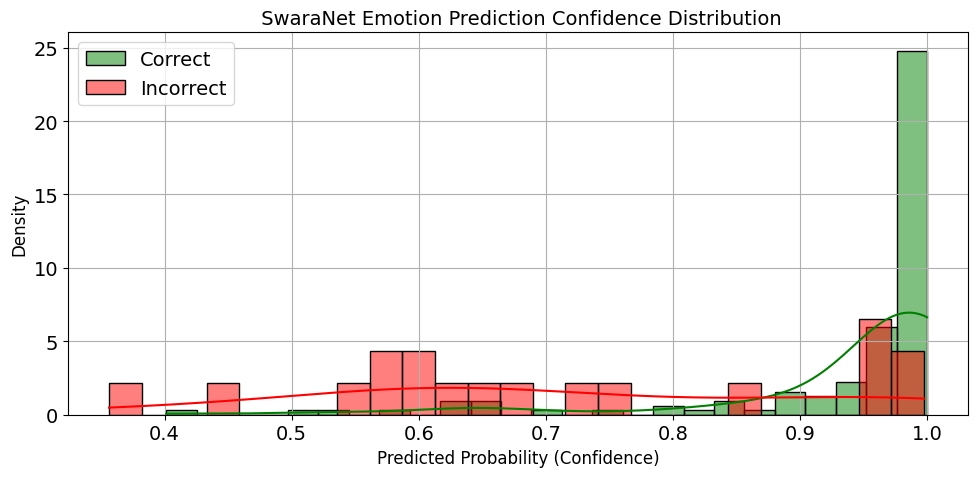

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#  Assuming these were computed already using SwaraNet
# y_pred = swaranet.predict(X_test)
# y_emotion_pred = np.argmax(y_pred[0], axis=1)
# y_emotion_true = np.argmax(y_emotion_test, axis=1)

#  Compute correctness
correct = (y_emotion_true == y_emotion_pred)

#  Get maximum predicted probability (confidence)
confidence_scores = np.max(y_pred[0], axis=1)

#  Plot confidence distribution
plt.figure(figsize=(10, 5))
sns.histplot(confidence_scores[correct], color="green", label="Correct", kde=True, stat='density', bins=25)
sns.histplot(confidence_scores[~correct], color="red", label="Incorrect", kde=True, stat='density', bins=25)

plt.title(" SwaraNet Emotion Prediction Confidence Distribution", fontsize=14)
plt.xlabel("Predicted Probability (Confidence)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [36]:
import numpy as np
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

# Recreate encoders using original labels
le_instr = LabelEncoder()
le_emo = LabelEncoder()

# Original labels (recreate these from training data source)
# Assuming y_instr and y_emotion are original string labels from your dataset
# You must redefine them if not already available in memory
# For example, reload from saved y labels if required

# Fit encoders to full label sets
le_instr.fit(["Flute", "Tabla", "Veena", "Violin"])
le_emo.fit(["Calm", "Happy", "Relax", "Sad"])

# Get predictions from model
emotion_pred_probs, instr_pred_probs = swaranet.predict(X_test)

# Decode predictions and ground truth
y_instr_true = np.argmax(y_instr_test, axis=1)
y_instr_pred = np.argmax(instr_pred_probs, axis=1)
y_emo_true = np.argmax(y_emotion_test, axis=1)
y_emo_pred = np.argmax(emotion_pred_probs, axis=1)

# Print classification reports
print(" Classification Report for Instruments:")
print(classification_report(y_instr_true, y_instr_pred, target_names=le_instr.classes_))

print("\n Classification Report for Emotions:")
print(classification_report(y_emo_true, y_emo_pred, target_names=le_emo.classes_))


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
 Classification Report for Instruments:
              precision    recall  f1-score   support

       Flute       1.00      1.00      1.00        21
       Tabla       1.00      1.00      1.00        48
       Veena       1.00      1.00      1.00        42
      Violin       1.00      1.00      1.00        40

    accuracy                           1.00       151
   macro avg       1.00      1.00      1.00       151
weighted avg       1.00      1.00      1.00       151


 Classification Report for Emotions:
              precision    recall  f1-score   support

        Calm       0.79      0.86      0.83        36
       Happy       0.98      0.95      0.96        43
       Relax       0.84      0.86      0.85        36
         Sad       0.91      0.83      0.87        36

    accuracy                           0.88       151
   macro avg       0.88      0.88      0.88       151
weighted avg       0.88      0.88      0.88       151



In [37]:
import numpy as np
import pandas as pd

#  Emotion class labels (used in SwaraNet)
emotion_labels = ['Calm', 'Happy', 'Relax', 'Sad']  # Update if your emotion order differs

#  Convert one-hot encoded emotion ground-truth to class indices
y_emotion_true = np.argmax(y_emotion_test, axis=1)

#  Extract predicted emotion indices from SwaraNet output
y_emotion_pred = np.argmax(y_pred[0], axis=1)  # y_pred[0] is emotion_output softmax

#  Identify misclassified samples
emotion_errors = np.where(y_emotion_pred != y_emotion_true)[0]

#  Construct error analysis table
data = {
    "Index": emotion_errors,
    "True Emotion": [emotion_labels[i] for i in y_emotion_true[emotion_errors]],
    "Predicted Emotion": [emotion_labels[i] for i in y_emotion_pred[emotion_errors]],
    "Confidence": [np.max(y_pred[0][i]) for i in emotion_errors]
}

error_df = pd.DataFrame(data)

#  Show top 10 misclassifications
print(" Top 10 Emotion Misclassifications (SwaraNet):")
print(error_df.head(10))


 Top 10 Emotion Misclassifications (SwaraNet):
   Index True Emotion Predicted Emotion  Confidence
0     12         Calm             Relax    0.989354
1     20        Relax              Calm    0.569553
2     24        Happy             Relax    0.860436
3     30        Relax              Calm    0.669466
4     31         Calm               Sad    0.356257
5     62        Happy               Sad    0.627324
6     64        Relax              Calm    0.583836
7     67          Sad              Calm    0.612728
8     73         Calm               Sad    0.731371
9     75          Sad             Relax    0.449122


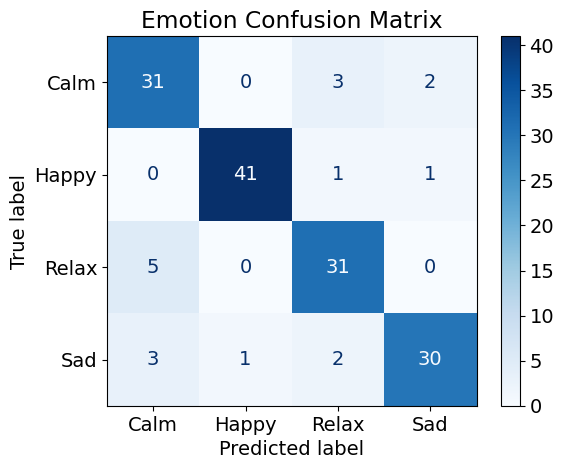

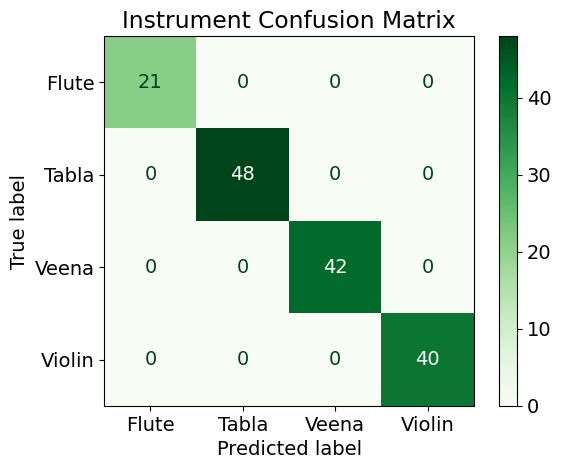

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_emotion = confusion_matrix(np.argmax(y_emotion_test, axis=1), np.argmax(y_pred[0], axis=1))
cm_instr = confusion_matrix(np.argmax(y_instr_test, axis=1), np.argmax(y_pred[1], axis=1))

ConfusionMatrixDisplay(cm_emotion, display_labels=emotion_labels).plot(cmap="Blues")
plt.title("Emotion Confusion Matrix")
plt.show()

ConfusionMatrixDisplay(cm_instr, display_labels=instrument_labels).plot(cmap="Greens")
plt.title("Instrument Confusion Matrix")
plt.show()


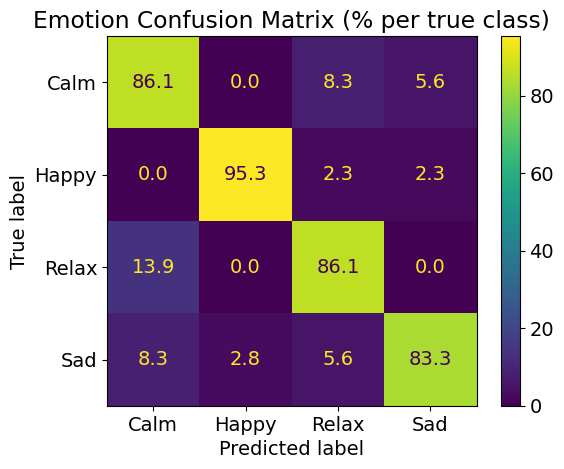

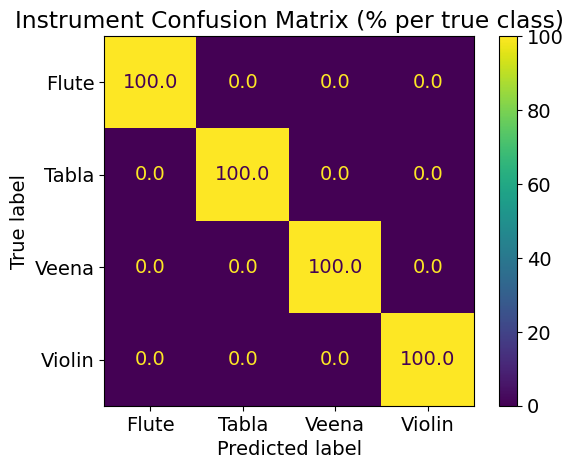

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Emotion
cm_emotion = confusion_matrix(
    np.argmax(y_emotion_test, axis=1),
    np.argmax(y_pred[0], axis=1),
    normalize='true'  # row-wise normalization (per true class)
)
cm_emotion_pct = cm_emotion * 100.0

disp_e = ConfusionMatrixDisplay(cm_emotion_pct, display_labels=emotion_labels)
disp_e.plot(values_format='.1f')  # shows values like 87.5 (i.e., %)
plt.title("Emotion Confusion Matrix (% per true class)")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

# Instrument
cm_instr = confusion_matrix(
    np.argmax(y_instr_test, axis=1),
    np.argmax(y_pred[1], axis=1),
    normalize='true'
)
cm_instr_pct = cm_instr * 100.0

disp_i = ConfusionMatrixDisplay(cm_instr_pct, display_labels=instrument_labels)
disp_i.plot(values_format='.1f')
plt.title("Instrument Confusion Matrix (% per true class)")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()


In [40]:
import os
import glob
import random
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from pathlib import Path

# -------- CONFIG --------
data_path = '/kaggle/input/indian-classical-instrument-music-emotion-dataset/Indian Classical Instrument Music Emotion Dataset'

instruments = ["Flute", "Tabla", "Veena", "Violin"]
emotions = ["Calm", "Happy", "Relax", "Sad"]

# STFT params (keep time axes aligned across features)
sr = 22050
n_fft = 2048
hop = 512
n_mels = 128

# Reproducibility for random choices
random.seed(42)

# Output directory
out_dir = Path("output_figures")
out_dir.mkdir(parents=True, exist_ok=True)

# If True -> plot ALL files per (instrument, emotion); False -> pick ONE random sample
PLOT_ALL_FILES = False

def find_audio_files(root):
    files = glob.glob(os.path.join(root, "**", "*.wav"), recursive=True)
    files += glob.glob(os.path.join(root, "**", "*.mp3"), recursive=True)
    return files

def compute_features(y, sr):
    # 1) Log-Mel (in dB)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop)
    log_mel = librosa.power_to_db(S, ref=np.max)
    # 2) Spectral Contrast
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr, n_fft=n_fft, hop_length=hop)
    # 3) Tonnetz (use harmonic component)
    y_harm = librosa.effects.harmonic(y)
    tonnetz = librosa.feature.tonnetz(y=y_harm, sr=sr)
    return log_mel, contrast, tonnetz

def plot_three_panels(log_mel, contrast, tonnetz, title, save_path):
    plt.rcParams.update({'font.size': 12})
    fig = plt.figure(figsize=(16, 10), dpi=300)

    # 1) Log-Mel
    ax1 = plt.subplot(3, 1, 1)
    img1 = librosa.display.specshow(log_mel, sr=sr, hop_length=hop, x_axis='time', y_axis='mel',
                                    cmap='magma', ax=ax1)
    fig.colorbar(img1, ax=ax1, format='%+2.0f dB')
    ax1.set_title('Log-Mel Spectrogram (dB)')

    # 2) Spectral Contrast
    ax2 = plt.subplot(3, 1, 2)
    img2 = librosa.display.specshow(contrast, sr=sr, hop_length=hop, x_axis='time', ax=ax2)
    fig.colorbar(img2, ax=ax2)
    ax2.set_ylabel('Bands')
    ax2.set_title('Spectral Contrast (per band)')

    # 3) Tonnetz
    ax3 = plt.subplot(3, 1, 3)
    img3 = librosa.display.specshow(tonnetz, sr=sr, x_axis='time', ax=ax3)
    fig.colorbar(img3, ax=ax3)
    ax3.set_ylabel('Tonnetz dims')
    ax3.set_title('Tonnetz (Tonal Centroids)')

    plt.suptitle(title)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.close(fig)

# -------- MAIN LOOP --------
missing = []
made = 0

for instr in instruments:
    for emo in emotions:
        category_root = os.path.join(data_path, instr, emo)
        files = find_audio_files(category_root)

        if not files:
            missing.append((instr, emo))
            continue

        if PLOT_ALL_FILES:
            selected_files = files
        else:
            selected_files = [random.choice(files)]

        for idx, fpath in enumerate(selected_files, start=1):
            # Load ~3 seconds for consistency (remove duration to use full file)
            y, _ = librosa.load(fpath, sr=sr, duration=3)

            # Edge case: silent/very short clips
            if y is None or len(y) < hop:
                continue

            log_mel, contrast, tonnetz = compute_features(y, sr)
            # Build filename; if plotting all files, add index to avoid overwrite
            base_name = f"{instr}_{emo}" + (f"_{idx:02d}" if PLOT_ALL_FILES else "")
            save_path = out_dir / f"{base_name}.png"
            title = f"{instr} — {emo}  |  {os.path.basename(fpath)}"
            plot_three_panels(log_mel, contrast, tonnetz, title, save_path)
            made += 1

print(f"Saved {made} figure(s) to: {out_dir.resolve()}")
if missing:
    print("No audio found for:", ", ".join([f"{i}/{e}" for i, e in missing]))


/usr/local/lib/python3.11/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=789
  warnings.warn(


Saved 16 figure(s) to: /kaggle/working/output_figures


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
 Classification Report - Instruments:
              precision    recall  f1-score   support

       Flute       1.00      1.00      1.00        21
       Tabla       1.00      1.00      1.00        48
       Veena       1.00      1.00      1.00        42
      Violin       1.00      1.00      1.00        40

    accuracy                           1.00       151
   macro avg       1.00      1.00      1.00       151
weighted avg       1.00      1.00      1.00       151


 Classification Report - Emotions:
              precision    recall  f1-score   support

        Calm       0.79      0.86      0.83        36
       Happy       0.98      0.95      0.96        43
       Relax       0.84      0.86      0.85        36
         Sad       0.91      0.83      0.87        36

    accuracy                           0.88       151
   macro avg       0.88      0.88      0.88       151
weighted avg       0.88      0.88      0.88       151



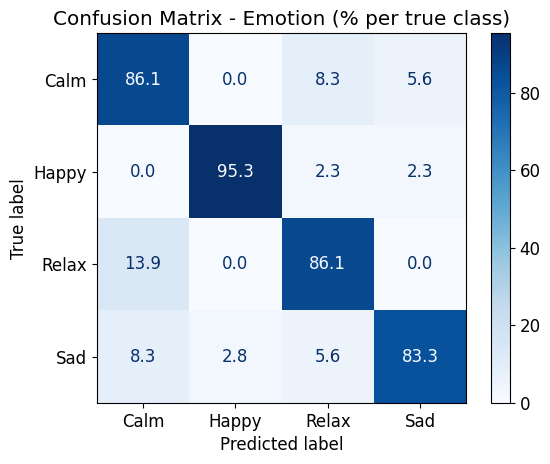

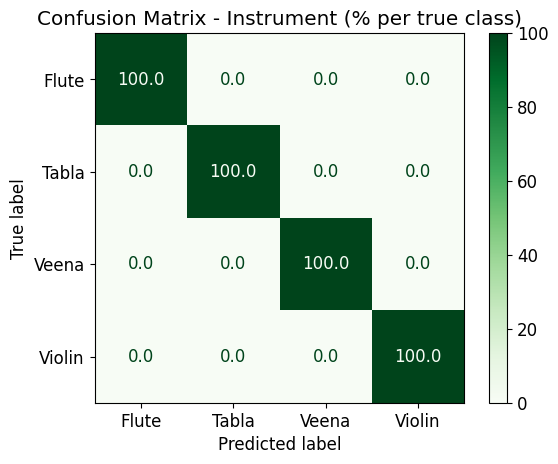


 Per-Instrument Confusion Matrices for Emotion (values are % per true class):

 Instrument: Flute


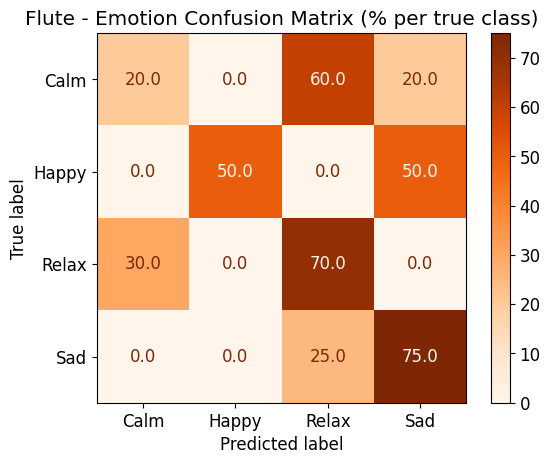


 Instrument: Tabla


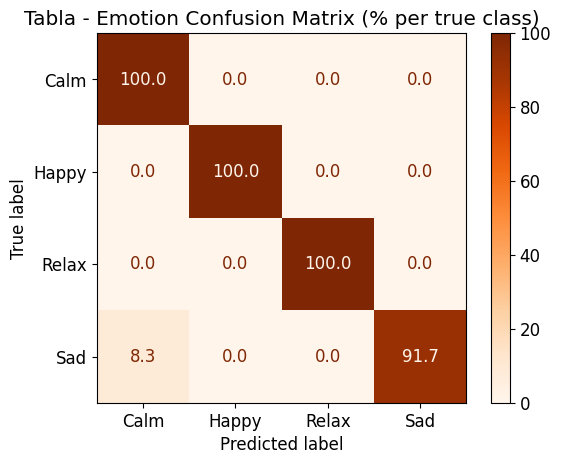


 Instrument: Veena


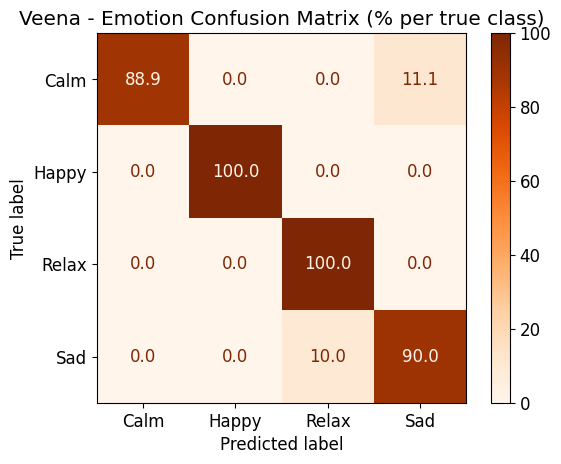


 Instrument: Violin


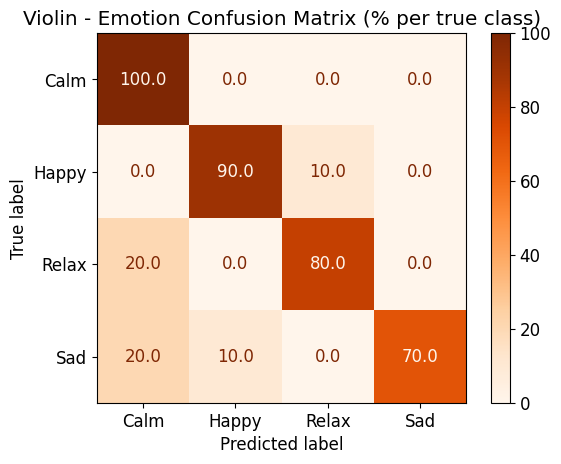

In [41]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# --- predictions as in your code ---
y_emotion_pred_probs, y_instr_pred_probs = swaranet.predict(X_test)
y_emotion_pred = np.argmax(y_emotion_pred_probs, axis=1)
y_instr_pred   = np.argmax(y_instr_pred_probs, axis=1)
y_emotion_true = np.argmax(y_emotion_test, axis=1)
y_instr_true   = np.argmax(y_instr_test, axis=1)

emotion_labels    = ['Calm', 'Happy', 'Relax', 'Sad']
instrument_labels = ['Flute', 'Tabla', 'Veena', 'Violin']

# --- classification reports (unchanged) ---
print(" Classification Report - Instruments:")
print(classification_report(y_instr_true, y_instr_pred, target_names=instrument_labels))
print("\n Classification Report - Emotions:")
print(classification_report(y_emotion_true, y_emotion_pred, target_names=emotion_labels))

# ---------- PERCENT CONFUSION MATRICES ----------
# Overall Emotion (row-wise % of true class)
cm_emo = confusion_matrix(y_emotion_true, y_emotion_pred, normalize='true') * 100.0
disp_emo = ConfusionMatrixDisplay(confusion_matrix=cm_emo, display_labels=emotion_labels)
disp_emo.plot(values_format='.1f', cmap='Blues')   # shows percentages like 87.5
plt.title("Confusion Matrix - Emotion (% per true class)")
plt.xlabel("Predicted label"); plt.ylabel("True label")
plt.show()

# Overall Instrument (row-wise % of true class)
cm_instr = confusion_matrix(y_instr_true, y_instr_pred, normalize='true') * 100.0
disp_instr = ConfusionMatrixDisplay(confusion_matrix=cm_instr, display_labels=instrument_labels)
disp_instr.plot(values_format='.1f', cmap='Greens')
plt.title("Confusion Matrix - Instrument (% per true class)")
plt.xlabel("Predicted label"); plt.ylabel("True label")
plt.show()

# Per-Instrument Emotion Confusion Matrices (row-wise % within each instrument's true emotion)
print("\n Per-Instrument Confusion Matrices for Emotion (values are % per true class):")
for idx, instr_name in enumerate(instrument_labels):
    instr_indices   = np.where(y_instr_true == idx)[0]
    y_emo_true_sub  = y_emotion_true[instr_indices]
    y_emo_pred_sub  = y_emotion_pred[instr_indices]

    if len(y_emo_true_sub) == 0:
        print(f"  Skipping {instr_name}: no test samples.")
        continue

    cm_sub = confusion_matrix(y_emo_true_sub, y_emo_pred_sub, normalize='true') * 100.0
    disp_sub = ConfusionMatrixDisplay(confusion_matrix=cm_sub, display_labels=emotion_labels)

    print(f"\n Instrument: {instr_name}")
    disp_sub.plot(values_format='.1f', cmap='Oranges')
    plt.title(f"{instr_name} - Emotion Confusion Matrix (% per true class)")
    plt.xlabel("Predicted label"); plt.ylabel("True label")
    plt.show()
